<h1> Purpose: </h1>

The purpose of this notebook is to conduct <strong> explanatory analysis </strong> using the medical claims dataset as part of the Fraud Data Scientist application at Accident Compensation Corporation. The data used in this notebook and its related analytical work is <strong>entirely fictitious </strong>. The fictitious reasoning to conduct the reasoning is that a staff member is suspious that some providers may be defrauding ACC by making faking invoice request.

NOTE: in the data_dictionary, although it's stated that "When providers bill multiple units of the same service on the same date for the same client, each unit appears as a separate row with the same claim_id, service_date, and client_id" this does not seem to hold true. If this were the case, then the count of DISTINCT claim_id != count of rows. In simple words, there would have been duplicated claim_id in the dataset, but this doesn't seem to be the case. I think, each claim_id is unique, and the only justifiable way that indicates a claim_id is part of a larger "unit" is if that claim_id is associated with the same service_id, provider_id, client_id and service_code (see below).


<strong>@author: Shakeel Ali </strong> <br>

In [1]:
# Importing useful libraries
# NOTE: You may not have all these libraries installed in your environment. Use !pip or related methods for installation.

import pandas as pd 
import duckdb # This is to query using SQL for easier interpretation
import matplotlib.pyplot as plt
from IPython.display import display # To display using loop
import seaborn as sns
import numpy as np



C:\Users\Admin\anaconda3\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
# Set to display scrollable rows

pd.reset_option("display.max_rows")

In [3]:
# Read csv

medical_claims_df = pd.read_csv("C:/Users/Admin/Desktop/ACC - Activity/data/medical_claims_dataset.csv")

In [4]:
# Check df [16,900 records == Yes!]

medical_claims_df

,claim_id,service_date,provider_id,provider_name,speciality,service_code,service_description,diagnosis_code,client_id,client_age,client_tla,billed_amount,allowed_amount,paid_amount
0,CLM000001,2023-01-01,PRV011,Fantail Chiropractic Services,Chiropractic,CHIRO001,Chiropractic Initial Consultation,M16.1,CLT21395,72,Wellington City,97.450,85.010,83.890
1,CLM000016,2023-01-01,PRV020,MegaFit Total Body Physio,Rehabilitation,MASSAGE002,Remedial Massage - 60min,M79.3,CLT38740,33,Queenstown-Lakes District,97.650,87.250,84.860
2,CLM000014,2023-01-01,PRV020,MegaFit Total Body Physio,Rehabilitation,MASSAGE002,Remedial Massage - 60min,M79.3,CLT38740,33,Queenstown-Lakes District,115.440,98.260,96.890
3,CLM000013,2023-01-01,PRV020,MegaFit Total Body Physio,Rehabilitation,MASSAGE002,Remedial Massage - 60min,M79.3,CLT38740,33,Queenstown-Lakes District,104.060,98.820,96.490
4,CLM000012,2023-01-01,PRV020,MegaFit Total Body Physio,Rehabilitation,MASSAGE002,Remedial Massage - 60min,M54.5,CLT38740,33,Queenstown-Lakes District,98.800,90.700,88.870
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16895,CLM016878,2024-12-31,PRV009,AllStar Sports Rehab Co,Sports Medicine,MASSAGE002,Remedial Massage - 60min,M79.3,CLT28462,77,Porirua City,80.900,70.050,69.960
16896,CLM016879,2024-12-31,PRV014,GoldStar Wellness Unlimited,Chiropractic,CHIRO003,Spinal Manipulation,M54.5,CLT15238,38,Auckland,148.008,136.020,129.408
16897,CLM016881,2024-12-31,PRV020,MegaFit Total Body Physio,Rehabilitation,PHYS004,Dry Needling,M25.561,CLT28042,59,Nelson City,77.690,67.020,66.350
16898,CLM016874,2024-12-31,PRV014,GoldStar Wellness Unlimited,Chiropractic,CHIRO002,Chiropractic Adjustment,M17.1,CLT15234,33,Napier City,154.152,135.744,132.132


In [5]:
# Count Unique claim_id. This means each claim_id occurs only once. 

'''
This bullet point below from the data_dictionary.pdf document is wrong. claim_id is not repeated, as each claim_id is unique within
the dataset. The only valid assumption that a claim belongs to a a unit of claims is if a claim_id also has similar
service_date, service_id, client_id, and provider_id to other claim_ids

• Multiple Rows: When providers bill multiple units of the same service on the same date for the same
client, each unit appears as a separate row with the same claim_id, service_date, and client_id



'''

# Query

sql_query = """
SELECT COUNT(DISTINCT (claim_id))
FROM medical_claims_df
"""

# Run Query
duckdb.query(sql_query)

┌──────────────────────────┐
│ count(DISTINCT claim_id) │
│          int64           │
├──────────────────────────┤
│                    16900 │
└──────────────────────────┘

In [6]:
# Describe the numerical/quantitative variables in the dataset.

medical_claims_df.describe()

,client_age,billed_amount,allowed_amount,paid_amount
count,16900.000000,16900.000000,16900.000000,16900.000000
mean,50.291183,91.489852,82.335849,80.295930
std,17.457856,23.197903,21.025063,20.532086
min,18.000000,22.500000,21.290000,21.140000
25%,36.000000,74.570000,67.117500,65.437500
50%,50.000000,91.020000,81.800000,79.705000
75%,65.000000,105.390000,94.840000,92.490000
max,85.000000,203.904000,191.376000,187.116000


In [7]:
# Describe the billed_amount by provider_name in the dataset

medical_claims_df.groupby('provider_name')['billed_amount'].describe()

,count,mean,std,min,25%,50%,75%,max
provider_name,,,,,,,,
Active Rehab Centre,385.0,85.423221,19.898649,44.06,70.6100,84.690,97.7000,144.620
AllStar Sports Rehab Co,1071.0,82.215005,22.104049,26.10,66.4350,83.040,98.5300,149.210
Athletes First Clinic,375.0,81.880907,23.882670,31.90,64.1850,81.130,97.8650,145.860
BackCare Chiropractic,400.0,77.662800,14.758630,37.50,67.0850,75.950,86.4275,136.150
Complete Care Osteopathy,385.0,92.434286,15.100395,58.65,80.8600,92.290,103.0300,140.830
Elite Sports Health,399.0,83.333609,24.702957,28.04,64.6850,83.510,100.2000,162.840
Fantail Chiropractic Services,418.0,78.587990,15.483070,39.11,68.6725,76.995,87.6900,128.580
GoldStar Wellness Unlimited,765.0,139.818225,23.216582,98.22,123.5800,136.440,155.9640,203.904
Harmony Osteo Clinic,376.0,92.097181,15.007225,50.00,81.2575,92.780,102.1150,136.600


In [8]:
# Check for duplicates -- If 16,900 then no duplicates exists

sql_query = """
SELECT COUNT (*)
FROM (
SELECT DISTINCT (*)
FROM medical_claims_df) AS SUBQUERY
"""

# Run Query
duckdb.query(sql_query).df()

,count_star()
0,16900


In [9]:
# Check Unique Providers (Should be 20)

sql_query = """
SELECT DISTINCT provider_id, provider_name
FROM medical_claims_df
"""

# Run Query
duckdb.query(sql_query).df()

,provider_id,provider_name
0,PRV009,AllStar Sports Rehab Co
1,PRV017,Kereru Osteopathy Group
2,PRV019,Recovery Plus Rehab
3,PRV020,MegaFit Total Body Physio
4,PRV015,Complete Care Osteopathy
5,PRV002,Kauri Physiotherapy Clinic
6,PRV010,Athletes First Clinic
7,PRV006,RapidFix Physiotherapy
8,PRV014,GoldStar Wellness Unlimited
9,PRV004,Tui Physiotherapy Centre


In [10]:
# Check Unique Clients (8,922 clients have made 16,900 claims in total)

sql_query = """
SELECT COUNT(DISTINCT(client_id))
FROM medical_claims_df
"""

# Run Query
duckdb.query(sql_query).df()

,count(DISTINCT client_id)
0,8922


In [11]:
# Check Unique client_tla (15 Unique locations)

sql_query = """
SELECT DISTINCT(client_tla)
FROM medical_claims_df
"""

# Run Query
duckdb.query(sql_query).df()

,client_tla
0,Queenstown-Lakes District
1,Whangarei District
2,Christchurch City
3,New Plymouth District
4,Porirua City
5,Napier City
6,Palmerston North City
7,Wellington City
8,Invercargill City
9,Nelson City


In [12]:
# It is possible that a Provider can operate from multiple locations. Let's check that


sql_query = """
SELECT DISTINCT provider_name, client_tla
FROM medical_claims_df
GROUP BY provider_name, client_tla
"""

# Run Query
duckdb.query(sql_query).df()

,provider_name,client_tla
0,Pohutukawa Physio Group,Christchurch City
1,Fantail Chiropractic Services,Hamilton City
2,Complete Care Osteopathy,Hamilton City
3,Kiwi Peak Sports Medicine,Porirua City
4,Kauri Physiotherapy Clinic,Rotorua District
...,...,...
315,Active Rehab Centre,Dunedin City
316,Wellness Spine Clinic,Auckland
317,Springbok Physiotherapy Ltd,Palmerston North City
318,Harmony Osteo Clinic,Hamilton City


In [13]:
# Get count of client_tla per provider


sql_query = """
SELECT provider_name, COUNT(DISTINCT(client_tla)) AS 'Total_client_tla'
FROM medical_claims_df
GROUP BY provider_name
ORDER BY COUNT(DISTINCT(client_tla)) DESC
"""

# Run Query
duckdb.query(sql_query).df()

,provider_name,Total_client_tla
0,MegaFit Total Body Physio,16
1,Tui Physiotherapy Centre,16
2,Kea Active Physio,16
3,Fantail Chiropractic Services,16
4,Kauri Physiotherapy Clinic,16
5,Active Rehab Centre,16
6,Elite Sports Health,16
7,Recovery Plus Rehab,16
8,Springbok Physiotherapy Ltd,16
9,RapidFix Physiotherapy,16


In [14]:
# Distinct services provided by the providers


sql_query = """
SELECT DISTINCT provider_name, service_description
FROM medical_claims_df
GROUP BY provider_name, service_description
"""

# Run Query
duckdb.query(sql_query).df()

,provider_name,service_description
0,Complete Care Osteopathy,Osteopathy Initial Assessment
1,RapidFix Physiotherapy,Physiotherapy Treatment - Extended
2,AllStar Sports Rehab Co,Exercise Rehabilitation Session
3,Springbok Physiotherapy Ltd,Physiotherapy Treatment - Standard
4,BackCare Chiropractic,Spinal Manipulation
...,...,...
162,Kiwi Peak Sports Medicine,Hydrotherapy Session
163,Recovery Plus Rehab,Exercise Rehabilitation Session
164,AllStar Sports Rehab Co,Remedial Massage - 60min
165,Recovery Plus Rehab,Physiotherapy Treatment - Standard


In [15]:
# Count of distinct services provided by the providers


sql_query = """
SELECT provider_name, COUNT(DISTINCT(service_description)) AS 'Total_Services_Provided'
FROM medical_claims_df
GROUP BY provider_name
ORDER BY COUNT(DISTINCT(service_description)) DESC
"""

# Run Query
duckdb.query(sql_query).df()

,provider_name,Total_Services_Provided
0,RapidFix Physiotherapy,18
1,Pohutukawa Physio Group,12
2,Kauri Physiotherapy Clinic,12
3,Kea Active Physio,12
4,Tui Physiotherapy Centre,12
5,Springbok Physiotherapy Ltd,12
6,AllStar Sports Rehab Co,11
7,Elite Sports Health,11
8,Athletes First Clinic,11
9,Kiwi Peak Sports Medicine,11


In [16]:
# This query calculates several other metrics which would help detect outliers.

sql_query = """
SELECT provider_name,
       COUNT(claim_id) AS 'Total_Claims',
       MIN(billed_amount) AS 'Min.Billed_Amount',
       AVG(billed_amount) AS 'Avg.Billed_Amount', 
       MAX(billed_amount) AS 'Max.Billed_Amount',
       SUM(billed_amount) AS 'Total.Billed_Amount', 
       SUM(billed_amount)/COUNT(DISTINCT(client_id)) AS 'Avg.Per_Client', 
       COUNT(DISTINCT(client_id)) AS 'Total_Clients',
       COUNT(claim_id)/COUNT(DISTINCT(client_id)) AS 'Avg.Claim_Per_Client',
       COUNT(DISTINCT(service_date)) AS 'Distinct_Service_Date',
       SUM(billed_amount)/COUNT(DISTINCT(service_date)) AS 'Avg.Billed_Amount_Per_Service_Date'
FROM medical_claims_df
GROUP BY provider_name
ORDER BY COUNT(claim_id)/COUNT(DISTINCT(client_id))  DESC -- Change the column and to see outliers more efficiently
"""

# Run Query
medical_claims_df_billed_amount_analytics = duckdb.query(sql_query).df()

# Display
medical_claims_df_billed_amount_analytics

,provider_name,Total_Claims,Min.Billed_Amount,Avg.Billed_Amount,Max.Billed_Amount,Total.Billed_Amount,Avg.Per_Client,Total_Clients,Avg.Claim_Per_Client,Distinct_Service_Date,Avg.Billed_Amount_Per_Service_Date
0,GoldStar Wellness Unlimited,765,98.22,139.818225,203.904,106960.942,21392.188400,5,153.000000,410,260.880346
1,MegaFit Total Body Physio,7733,60.02,93.874908,137.490,725934.660,568.914310,1276,6.060345,614,1182.304007
2,AllStar Sports Rehab Co,1071,26.10,82.215005,149.210,88052.270,116.163945,758,1.412929,471,186.947495
3,RapidFix Physiotherapy,1054,27.06,96.007761,172.690,101192.180,96.649647,1047,1.006686,558,181.347993
4,Kiwi Peak Sports Medicine,370,28.80,81.640757,147.330,30207.080,82.084457,368,1.005435,306,98.715948
5,Kauri Physiotherapy Clinic,387,22.50,81.299897,150.120,31463.060,81.722234,385,1.005195,308,102.152792
6,Complete Care Osteopathy,385,58.65,92.434286,140.830,35587.200,92.675000,384,1.002604,311,114.428296
7,Wellness Spine Clinic,396,40.93,77.079596,124.160,30523.520,77.274734,395,1.002532,299,102.085351
8,Fantail Chiropractic Services,418,39.11,78.587990,128.580,32849.780,78.776451,417,1.002398,334,98.352635
9,Athletes First Clinic,375,31.90,81.880907,145.860,30705.340,81.880907,375,1.000000,291,105.516632


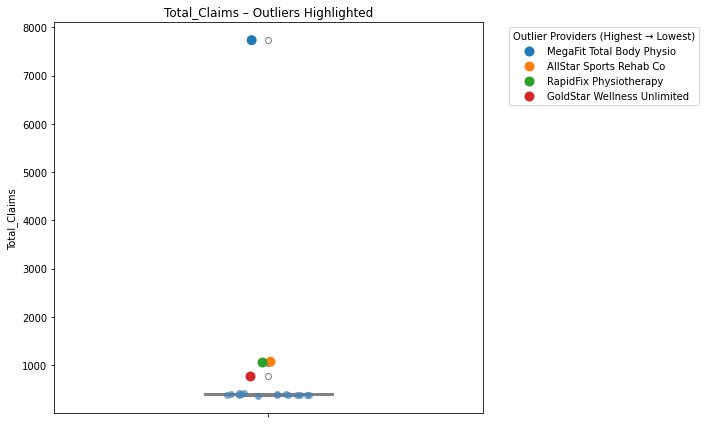

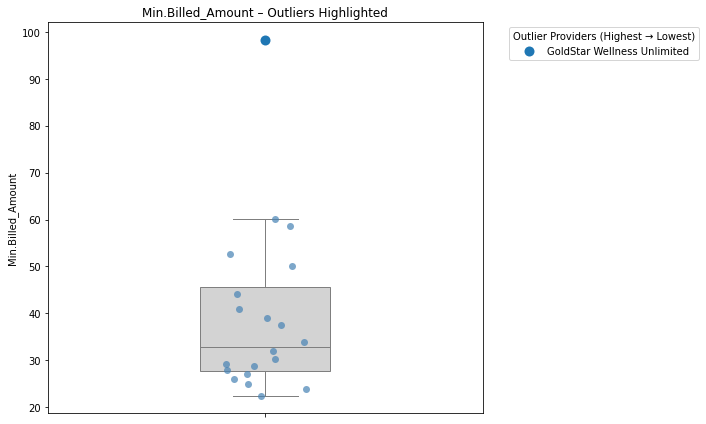

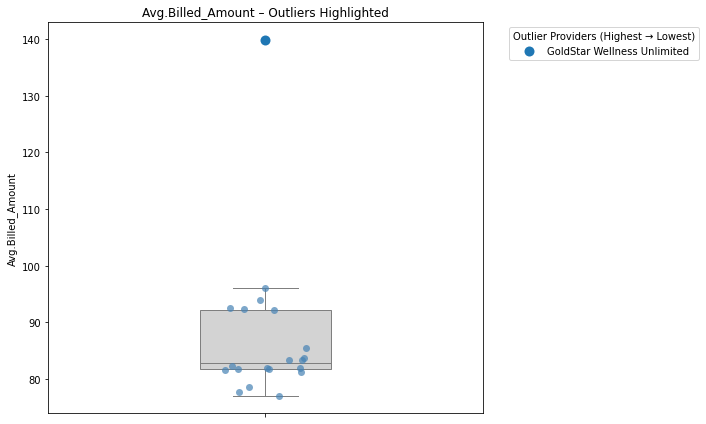

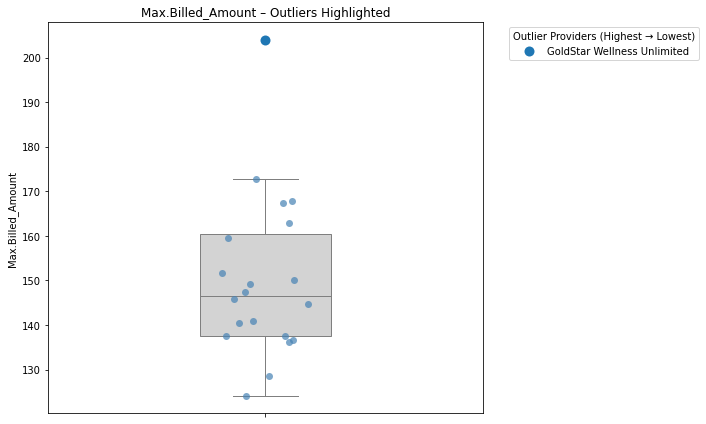

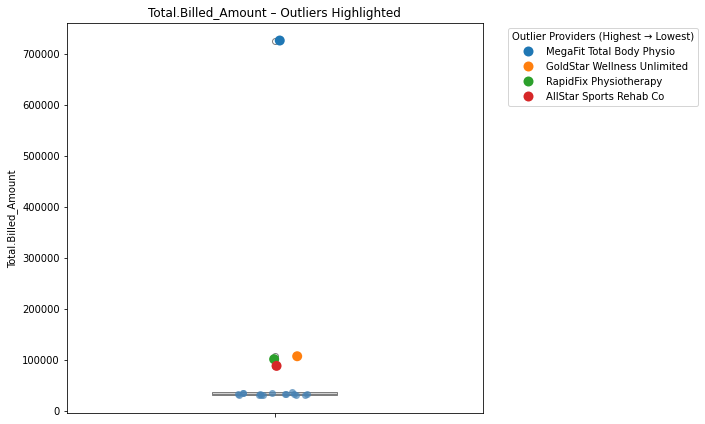

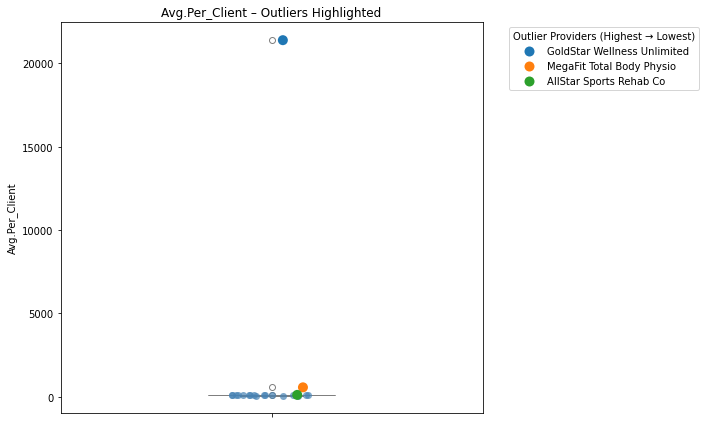

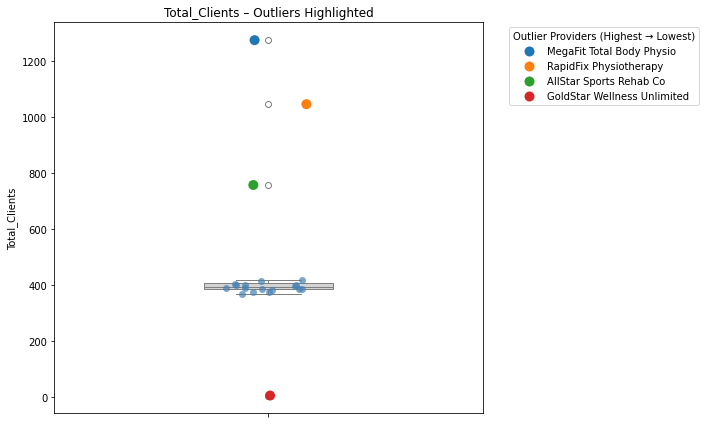

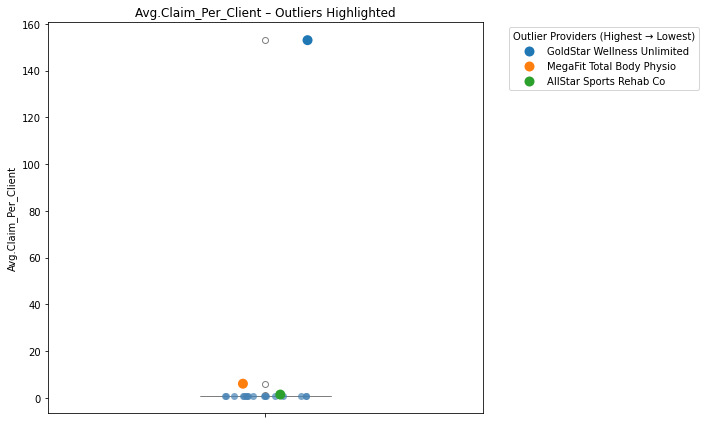

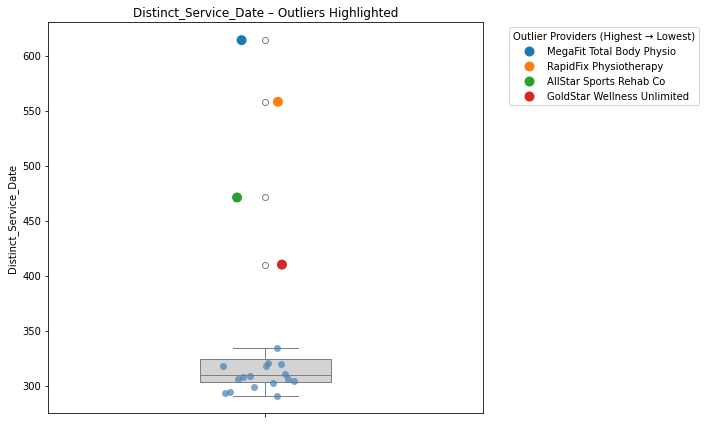

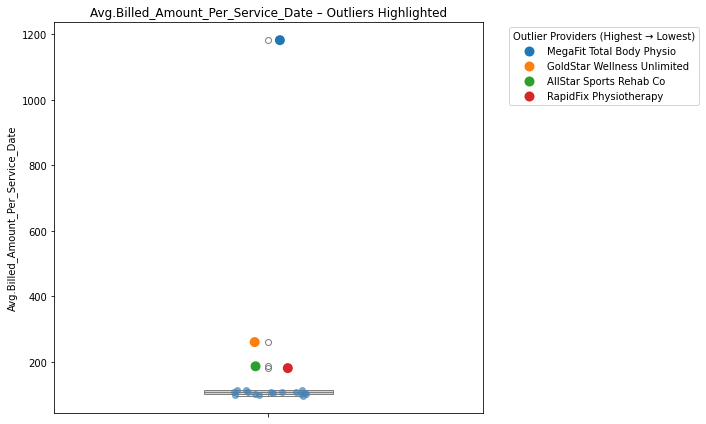

In [17]:
# This function is used to create a strip plot, taking as parameters a dataframe, and the column within the data-frame. 
# The below plots shows the outliers, which is useful in detecting suspicious providers.


np.random.seed(42)

def plot_highlight_provider_outliers(df, metric):
    
    # ---- Compute IQR outliers ----
    Q1 = df[metric].quantile(0.25)
    Q3 = df[metric].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    lower_bound = Q1 - 1.5 * IQR
    
    df = df.copy()
    df["is_outlier"] = (df[metric] > upper_bound) | (df[metric] < lower_bound)
    
    outliers = df[df["is_outlier"]].sort_values(metric, ascending=False)
    normal = df[~df["is_outlier"]]
    
    # Order providers by descending metric value
    hue_order = outliers["provider_name"].tolist()
    
    plt.figure(figsize=(10,6))
    
    # Boxplot
    sns.boxplot(
        y=df[metric],
        color="lightgrey",
        width=0.3
    )
    
    # Normal providers
    sns.stripplot(
        y=normal[metric],
        color="steelblue",
        jitter=True,
        size=7,
        alpha=0.7
    )
    
    # Outliers coloured & sorted
    if not outliers.empty:
        sns.stripplot(
            data=outliers,
            y=metric,
            hue="provider_name",
            hue_order=hue_order,
            jitter=True,
            size=10,
            palette="tab10"
        )
        
        plt.legend(
            title="Outlier Providers (Highest → Lowest)",
            bbox_to_anchor=(1.05, 1),
            loc="upper left"
        )
    
    plt.title(f'{metric} – Outliers Highlighted')
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()

    
# Select the metrics that you want to loop through
selected_columns = [
    "Total_Claims",
    "Min.Billed_Amount",
    "Avg.Billed_Amount",
    "Max.Billed_Amount",
    "Total.Billed_Amount",
    "Avg.Per_Client",
    "Total_Clients",
    "Avg.Claim_Per_Client",
    "Distinct_Service_Date",
    "Avg.Billed_Amount_Per_Service_Date" 
]


for columns in selected_columns:
    plot_highlight_provider_outliers(medical_claims_df_billed_amount_analytics , columns)

In [18]:
'''
Based on the above metrics, the following looks alarming.

Total Claims:
    1. MegaFit Total Body Physio - 7733
    2. AllStar Sports Rehab Co - 1071
    3. RapidFix Physiotherapy - 1054
    4. GoldStar Wellness Unlimited - 765

Highest Min.Billed Amounts:
    1. GoldStar Wellness Unlimited - $98.22

Highest Avg.Billed Amounts:
    1. GoldStar Wellness Unlimited - $139.818225

Highest Max.Billed Amounts:
    1. GoldStar Wellness Unlimited - $203.904
    2. RapidFix Physiotherapy - $172.690

Highest Total(Sum).Billed Amounts:
    1. MegaFit Total Body Physio - $725,934.660
    2. GoldStar Wellness Unlimited - $106,960.942
    3. RapidFix Physiotherapy - $101,192.180
    4. AllStar Sports Rehab Co - $88,052.270
    
Highest Avg.Billed Amount Per Client:
    1. GoldStar Wellness Unlimited - $21,392.188400
    2. MegaFit Total Body Physio - $568.914310
    3. AllStar Sports Rehab Co - $116.163945
    
Highest Total Clients:
    1. MegaFit Total Body Physio - 1276
    2. RapidFix Physiotherapy - 1047
    3. AllStar Sports Rehab Co - 758
    
Highest Average Claim Per Client
    1. GoldStar Wellness Unlimited - 153.000000
    2. MegaFit Total Body Physio - 6.060345
    
Highest Avg.Per Service Day Billed Amount
    1. MegaFit Total Body Physio - $1,182.304007
    2. GoldStar Wellness Unlimited - $260.880346
    3. AllStar Sports Rehab Co - $186.947495
    3. RapidFix Physiotherapy - $181.347993


Based on the above the following providers have several
'''

'\nBased on the above metrics, the following looks alarming.\n\nTotal Claims:\n    1. MegaFit Total Body Physio - 7733\n    2. AllStar Sports Rehab Co - 1071\n    3. RapidFix Physiotherapy - 1054\n    4. GoldStar Wellness Unlimited - 765\n\nHighest Min.Billed Amounts:\n    1. GoldStar Wellness Unlimited - $98.22\n\nHighest Avg.Billed Amounts:\n    1. GoldStar Wellness Unlimited - $139.818225\n\nHighest Max.Billed Amounts:\n    1. GoldStar Wellness Unlimited - $203.904\n    2. RapidFix Physiotherapy - $172.690\n\nHighest Total(Sum).Billed Amounts:\n    1. MegaFit Total Body Physio - $725,934.660\n    2. GoldStar Wellness Unlimited - $106,960.942\n    3. RapidFix Physiotherapy - $101,192.180\n    4. AllStar Sports Rehab Co - $88,052.270\n    \nHighest Avg.Billed Amount Per Client:\n    1. GoldStar Wellness Unlimited - $21,392.188400\n    2. MegaFit Total Body Physio - $568.914310\n    3. AllStar Sports Rehab Co - $116.163945\n    \nHighest Total Clients:\n    1. MegaFit Total Body Physio

In [19]:
# Find out the number of claims for each Client and Provider combination.


# Query

sql_query = """
SELECT provider_name, provider_id, client_id, COUNT(claim_id) AS 'Total Number of Claims'
FROM medical_claims_df
GROUP BY provider_name, provider_id, client_id
ORDER BY COUNT(claim_id) DESC
"""

# Run Query
duckdb.query(sql_query)


┌───────────────────────────────┬─────────────┬───────────┬────────────────────────┐
│         provider_name         │ provider_id │ client_id │ Total Number of Claims │
│            varchar            │   varchar   │  varchar  │         int64          │
├───────────────────────────────┼─────────────┼───────────┼────────────────────────┤
│ GoldStar Wellness Unlimited   │ PRV014      │ CLT15237  │                    163 │
│ GoldStar Wellness Unlimited   │ PRV014      │ CLT15235  │                    159 │
│ GoldStar Wellness Unlimited   │ PRV014      │ CLT15234  │                    152 │
│ GoldStar Wellness Unlimited   │ PRV014      │ CLT15236  │                    146 │
│ GoldStar Wellness Unlimited   │ PRV014      │ CLT15238  │                    145 │
│ MegaFit Total Body Physio     │ PRV020      │ CLT49660  │                     15 │
│ MegaFit Total Body Physio     │ PRV020      │ CLT11950  │                     12 │
│ MegaFit Total Body Physio     │ PRV020      │ CLT63102  │      

From the above, we can see that the provider <strong> GoldStar Wellness Unlimited <strong> has five 100+ claims for clients 5 different clients, all of which are considerably higher than other organizations.

We will now dive deep into understanding these claims, checking the claims against client_id: CLT15237 first and see if we find anything out of the ordinary.

In [20]:
# See all the claims made by Provider "GoldStar Wellness Unlimited" made against client_id "CLT15237" ordered from earliest
# to latest service_date

sql_query = """
SELECT *
FROM medical_claims_df
WHERE provider_name = 'GoldStar Wellness Unlimited' AND client_id = 'CLT15237'
ORDER BY service_date 
"""

# Run Query
duckdb.query(sql_query).df()


,claim_id,service_date,provider_id,provider_name,speciality,service_code,service_description,diagnosis_code,client_id,client_age,client_tla,billed_amount,allowed_amount,paid_amount
0,CLM000031,2023-01-02,PRV014,GoldStar Wellness Unlimited,Chiropractic,CHIRO002,Chiropractic Adjustment,M23.9,CLT15237,77,Wellington City,104.660,89.980,87.420
1,CLM000247,2023-01-12,PRV014,GoldStar Wellness Unlimited,Chiropractic,CHIRO002,Chiropractic Adjustment,M25.561,CLT15237,29,Nelson City,132.860,119.130,118.410
2,CLM000237,2023-01-12,PRV014,GoldStar Wellness Unlimited,Chiropractic,CHIRO003,Spinal Manipulation,M51.2,CLT15237,84,Whangarei District,107.770,102.080,100.250
3,CLM000536,2023-01-26,PRV014,GoldStar Wellness Unlimited,Chiropractic,CHIRO003,Spinal Manipulation,M16.1,CLT15237,54,Invercargill City,123.010,111.580,109.720
4,CLM000614,2023-01-30,PRV014,GoldStar Wellness Unlimited,Chiropractic,CHIRO002,Chiropractic Adjustment,M54.5,CLT15237,51,Christchurch City,121.860,114.500,113.710
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
158,CLM016654,2024-12-23,PRV014,GoldStar Wellness Unlimited,Chiropractic,CHIRO003,Spinal Manipulation,M79.3,CLT15237,31,Auckland,150.936,136.044,132.348
159,CLM016700,2024-12-24,PRV014,GoldStar Wellness Unlimited,Chiropractic,CHIRO002,Chiropractic Adjustment,M75.1,CLT15237,34,Hamilton City,140.568,119.508,118.860
160,CLM016776,2024-12-27,PRV014,GoldStar Wellness Unlimited,Chiropractic,CHIRO001,Chiropractic Initial Consultation,M25.561,CLT15237,80,Tauranga City,176.508,152.244,144.696
161,CLM016816,2024-12-29,PRV014,GoldStar Wellness Unlimited,Chiropractic,CHIRO001,Chiropractic Initial Consultation,M54.5,CLT15237,78,Dunedin City,199.260,186.168,186.096


From the above, we can see that the <strong>age of the client is not consistent </strong>. For example, on 2nd January, 2023, the age of client_id CLT15237 is 77, however on the 12th of January, 2023, the age of the client is 29. This inconsistency in age is highlighted in several other claims by this provider against this client.

Moreover, we can also see that the Territorial Local Authority (client_tla) of where the client resides also changes. For example, on 2nd January, 2023, the client_tla of the client was Wellington City and on 12th January, 2023 it was Nelson City.

Given the number/count of claims sought, and the inconsistency of the client's age, it does raise suspicion for further investigation of the Provider and the Client. It is important to note that this might be a data integrity issue and not really a fraud-related issue. Moreover, the billed amount for the same service is different as well.

Next will we check if for some of the clients if the above findings is similar.

In [21]:
# See all the claims made by Provider "GoldStar Wellness Unlimited" made against client_id "CLT15235" ordered from earliest
# to latest service_date

sql_query = """
SELECT *
FROM medical_claims_df
WHERE provider_name = 'GoldStar Wellness Unlimited' AND client_id = 'CLT15235'
ORDER BY service_date 
"""

# Run Query
duckdb.query(sql_query).df()


,claim_id,service_date,provider_id,provider_name,speciality,service_code,service_description,diagnosis_code,client_id,client_age,client_tla,billed_amount,allowed_amount,paid_amount
0,CLM000063,2023-01-03,PRV014,GoldStar Wellness Unlimited,Chiropractic,CHIRO003,Spinal Manipulation,M16.1,CLT15235,78,Dunedin City,129.550,116.140,112.900
1,CLM000050,2023-01-03,PRV014,GoldStar Wellness Unlimited,Chiropractic,CHIRO002,Chiropractic Adjustment,M79.3,CLT15235,40,Invercargill City,132.080,122.170,121.720
2,CLM000078,2023-01-05,PRV014,GoldStar Wellness Unlimited,Chiropractic,CHIRO001,Chiropractic Initial Consultation,M51.2,CLT15235,32,Palmerston North City,134.970,115.000,110.130
3,CLM000314,2023-01-15,PRV014,GoldStar Wellness Unlimited,Chiropractic,CHIRO002,Chiropractic Adjustment,M77.9,CLT15235,39,Tauranga City,131.830,120.510,117.440
4,CLM000319,2023-01-16,PRV014,GoldStar Wellness Unlimited,Chiropractic,CHIRO001,Chiropractic Initial Consultation,M75.1,CLT15235,28,Wellington City,142.790,127.170,124.400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154,CLM016601,2024-12-21,PRV014,GoldStar Wellness Unlimited,Chiropractic,CHIRO003,Spinal Manipulation,M16.1,CLT15235,20,Tauranga City,165.972,154.092,153.156
155,CLM016639,2024-12-22,PRV014,GoldStar Wellness Unlimited,Chiropractic,CHIRO002,Chiropractic Adjustment,M79.3,CLT15235,69,Dunedin City,129.024,118.980,117.420
156,CLM016667,2024-12-23,PRV014,GoldStar Wellness Unlimited,Chiropractic,CHIRO002,Chiropractic Adjustment,M17.1,CLT15235,35,Queenstown-Lakes District,154.704,142.188,139.164
157,CLM016689,2024-12-24,PRV014,GoldStar Wellness Unlimited,Chiropractic,CHIRO003,Spinal Manipulation,M16.1,CLT15235,81,Queenstown-Lakes District,130.008,116.520,115.788


Interestingly, we also find that the client_age for client_id CLT15235 changes from 78 to 40 on the same date, that is 3rd January, 2023. Moreover, on this particular date, the individual's client_tla changed from Dunedin City to Invercargill City as well, while 2 days later, the client's client_tla changed to Palmerston North City.

This does contribute to the suspicion  raised prior, and thus more investigation must be conducted on GoldStar Wellness Unlimited as well as the clients whom the organization provided chiropractic services to.

<strong> We will now look at the count of different bill amount by providers for the same service and diagnosis provided. </strong>

NOTE: diagnosis is added due to robustness/benefit-of-doubt that somehow different diagnosis leads to different billed amounts. Hence, if it's the same provider, same service, same diagnosis, and same location (client tla), then the billed amount should be the same.

In [22]:
# Count the number of different billed_amount to clients for the same service_code,client_tla (alternative for location), and diagnosis_code

sql_query = """
SELECT provider_name, service_code, diagnosis_code, client_tla, COUNT(DISTINCT(billed_amount)) AS 'Number of Distinct Billed Amount'
FROM medical_claims_df
GROUP BY provider_name, service_code, diagnosis_code, client_tla
ORDER BY COUNT(DISTINCT(billed_amount)) DESC
"""

# Run Query
duckdb.query(sql_query).df()


,provider_name,service_code,diagnosis_code,client_tla,Number of Distinct Billed Amount
0,MegaFit Total Body Physio,REHAB002,M54.5,Christchurch City,43
1,MegaFit Total Body Physio,REHAB002,M79.3,Christchurch City,43
2,MegaFit Total Body Physio,PHYS005,M54.5,Invercargill City,38
3,MegaFit Total Body Physio,PHYS004,M25.561,Dunedin City,37
4,MegaFit Total Body Physio,PHYS005,M25.561,Rotorua District,37
...,...,...,...,...,...
7138,Tui Physiotherapy Centre,PHYS001,M17.1,Invercargill City,1
7139,Wellness Spine Clinic,CHIRO003,M77.9,Upper Hutt City,1
7140,AllStar Sports Rehab Co,REHAB002,M17.1,Palmerston North City,1
7141,Kauri Physiotherapy Clinic,REHAB001,M79.3,Palmerston North City,1


From the above, it looks like MegaFit Total Body Physio is providing different billed amounts (billed_amount) for the same service (service_code), same diagnosis (diagnosis_code), and within the same apparent location (client_tla).

However, one thing to note is currently, we are not controlling for time-variant. For now, let's dig deeper into MegaFit Total Body Physio.

The other thing to note is, even though one perception is, for example, for service_code REHAB002 and diagnosis_code M79.3 and in the client_tla Christchurch City the number of billed amount should be 1, that is the same amount is billed for the same service, and this is contradictory to what MegaFit Total Body Physio billed, it could be assumed that in reality, for the same service_code, there might be different treatments done which then explains the different billed amounts. 


In [23]:
# Confirm the different Billed Amount for same service (REHADB002) and diagnosis_code and client_tla

sql_query = """
SELECT *
FROM medical_claims_df
WHERE provider_name = 'MegaFit Total Body Physio' AND 
      service_code = 'REHAB002' AND
      diagnosis_code = 'M79.3' AND 
      client_tla = 'Christchurch City'
"""
  
# Run Query
duckdb.query(sql_query).df()

,claim_id,service_date,provider_id,provider_name,speciality,service_code,service_description,diagnosis_code,client_id,client_age,client_tla,billed_amount,allowed_amount,paid_amount
0,CLM000108,2023-01-06,PRV020,MegaFit Total Body Physio,Rehabilitation,REHAB002,Hydrotherapy Session,M79.3,CLT74716,53,Christchurch City,104.66,98.55,94.51
1,CLM000105,2023-01-06,PRV020,MegaFit Total Body Physio,Rehabilitation,REHAB002,Hydrotherapy Session,M79.3,CLT74716,53,Christchurch City,95.63,82.16,82.01
2,CLM000104,2023-01-06,PRV020,MegaFit Total Body Physio,Rehabilitation,REHAB002,Hydrotherapy Session,M79.3,CLT74716,53,Christchurch City,103.46,97.14,95.85
3,CLM000107,2023-01-06,PRV020,MegaFit Total Body Physio,Rehabilitation,REHAB002,Hydrotherapy Session,M79.3,CLT74716,53,Christchurch City,102.97,95.38,91.44
4,CLM001108,2023-02-22,PRV020,MegaFit Total Body Physio,Rehabilitation,REHAB002,Hydrotherapy Session,M79.3,CLT74086,38,Christchurch City,102.86,97.05,94.01
5,CLM001103,2023-02-22,PRV020,MegaFit Total Body Physio,Rehabilitation,REHAB002,Hydrotherapy Session,M79.3,CLT74086,38,Christchurch City,98.42,88.76,85.12
6,CLM001102,2023-02-22,PRV020,MegaFit Total Body Physio,Rehabilitation,REHAB002,Hydrotherapy Session,M79.3,CLT74086,38,Christchurch City,101.44,93.85,92.18
7,CLM001105,2023-02-22,PRV020,MegaFit Total Body Physio,Rehabilitation,REHAB002,Hydrotherapy Session,M79.3,CLT74086,38,Christchurch City,100.66,91.41,89.76
8,CLM004509,2023-07-16,PRV020,MegaFit Total Body Physio,Rehabilitation,REHAB002,Hydrotherapy Session,M79.3,CLT75885,70,Christchurch City,98.39,91.94,89.26
9,CLM004510,2023-07-16,PRV020,MegaFit Total Body Physio,Rehabilitation,REHAB002,Hydrotherapy Session,M79.3,CLT75885,70,Christchurch City,104.88,89.16,88.34


From the above, we can clearly see that <strong>MegaFit Total Body Physio </strong> on <strong>2023-01-06</strong> provided total of four <strong>REHAB002</strong> service to client <strong>CLT74716</strong> with a diagnosis of <strong>M79.3</strong> with the client_tla being <strong>Christchurch City</strong>. An expectation would be that the billing amount by the Provider would be the same, given the same service, client, location (proxy), diagnosis, and day, however, this isn't true. There are four different bills charged. Further investigation needs to be done as to why this is occuring.

We will now look at those Providers who have this similar trend.

In [24]:
# Count the number of different billed_amount to clients for the same service_code,client_tla (alternative for location), 
# diagnosis_code, and service_date

sql_query = """
SELECT provider_name, 
       service_code, 
       diagnosis_code, 
       client_tla,
       service_date,
       COUNT(DISTINCT(billed_amount)) AS 'Number of Distinct Billed Amount'
FROM medical_claims_df
GROUP BY provider_name, service_code, diagnosis_code, client_tla, service_date
HAVING  COUNT(DISTINCT(billed_amount)) > 1
ORDER BY COUNT(DISTINCT(billed_amount)) DESC
"""

# Run Query
duckdb.query(sql_query).df()

,provider_name,service_code,diagnosis_code,client_tla,service_date,Number of Distinct Billed Amount
0,MegaFit Total Body Physio,PHYS004,M54.5,Auckland,2023-05-22,7
1,MegaFit Total Body Physio,PHYS003,M25.561,Whangarei District,2024-02-06,7
2,MegaFit Total Body Physio,REHAB002,M25.561,Invercargill City,2024-06-21,7
3,MegaFit Total Body Physio,PHYS001,M25.561,Queenstown-Lakes District,2024-04-19,7
4,MegaFit Total Body Physio,MASSAGE001,M54.5,Auckland,2023-01-25,7
...,...,...,...,...,...,...
2751,AllStar Sports Rehab Co,SPORTS001,M75.1,Dunedin City,2023-03-02,2
2752,MegaFit Total Body Physio,PHYS002,M54.5,Napier City,2023-09-03,2
2753,MegaFit Total Body Physio,REHAB002,M25.561,Hamilton City,2024-06-11,2
2754,MegaFit Total Body Physio,PHYS002,M54.5,Upper Hutt City,2024-07-16,2


In [25]:
# Count the number of different billed_amount to clients for the same service_code,client_tla (alternative for location), 
# diagnosis_code, and service_date

sql_query = """
SELECT provider_name, 
       service_code, 
       diagnosis_code, 
       client_tla,
       service_date,
       client_id,
       COUNT(DISTINCT(billed_amount)) AS 'Number of Distinct Billed Amount'
FROM medical_claims_df
GROUP BY provider_name, service_code, diagnosis_code, client_tla, service_date, client_id
HAVING  COUNT(DISTINCT(billed_amount)) > 1
ORDER BY COUNT(DISTINCT(billed_amount)) DESC
"""

# Run Query
duckdb.query(sql_query).df()

,provider_name,service_code,diagnosis_code,client_tla,service_date,client_id,Number of Distinct Billed Amount
0,MegaFit Total Body Physio,PHYS004,M54.5,Auckland,2023-05-22,CLT21864,7
1,MegaFit Total Body Physio,MASSAGE001,M54.5,Auckland,2023-01-25,CLT34973,7
2,MegaFit Total Body Physio,PHYS001,M25.561,Queenstown-Lakes District,2024-04-19,CLT77228,7
3,MegaFit Total Body Physio,PHYS003,M25.561,Whangarei District,2024-02-06,CLT99831,7
4,MegaFit Total Body Physio,REHAB002,M25.561,Invercargill City,2024-06-21,CLT87950,7
...,...,...,...,...,...,...,...
2747,AllStar Sports Rehab Co,PHYS004,M75.1,Whangarei District,2024-03-21,CLT63850,2
2748,MegaFit Total Body Physio,PHYS005,M25.561,Rotorua District,2023-10-12,CLT86676,2
2749,AllStar Sports Rehab Co,PHYS004,M23.9,Napier City,2024-02-29,CLT32218,2
2750,MegaFit Total Body Physio,PHYS003,M79.3,Christchurch City,2023-07-06,CLT44367,2


From the above, we can see that MegaFit Total Body Physio billed 7 different amounts by providing the same service_code (REHAB002) to client_id CLT87950, who had the same diagnosis_code, on the same service_date (2024-06-01) in the same client_tla. Why the different billed amounts? Further investigation needs to be done.

Next we will find if there are individual who had multiple of the same service_code, on the same day (service_date), in the same client_tla, and the same diagnosis_code but rather than having different billed_amounts, had the same billed_amount.

In [26]:
# With the same client_id, provider_id, service_id, service_date, client_tla, and diagnosis_code derive the Number_Of_Claims and
# Number of Distinct Billed Amounts.
# Ideally, the Number_Of_Claims can be >=1 but the Distinct_Billed_Amount count should always be 1.

sql_query = """
WITH claims AS (
SELECT provider_name, 
       service_code, 
       diagnosis_code, 
       client_tla,
       service_date,
       client_id,
       COUNT(DISTINCT(claim_id)) AS 'Number_Of_Claims'
FROM medical_claims_df
GROUP BY provider_name, service_code, diagnosis_code, client_tla, service_date, client_id
),


bill_count AS (
SELECT provider_name, 
       service_code, 
       diagnosis_code, 
       client_tla,
       service_date,
       client_id,
       COUNT(DISTINCT(billed_amount)) AS 'Number_Of_Distinct_Billed_Amounts'
FROM medical_claims_df
GROUP BY provider_name, service_code, diagnosis_code, client_tla, service_date, client_id)

SELECT *
FROM (
SELECT a.*, b.Number_Of_Claims
FROM bill_count AS a
LEFT JOIN claims AS b
ON 
    a.provider_name = b.provider_name AND 
    a.service_code = b.service_code AND 
    a.diagnosis_code = b.diagnosis_code AND
    a.client_tla = b.client_tla AND
    a.service_date = b.service_date AND
    a.client_id = b.client_id)
WHERE Number_Of_Claims != Number_Of_Distinct_Billed_Amounts
"""

# Run Query
duckdb.query(sql_query).df()

,provider_name,service_code,diagnosis_code,client_tla,service_date,client_id,Number_Of_Distinct_Billed_Amounts,Number_Of_Claims
0,MegaFit Total Body Physio,PHYS001,M25.561,Upper Hutt City,2024-08-27,CLT36996,2,3
1,MegaFit Total Body Physio,PHYS004,M79.3,New Plymouth District,2023-05-06,CLT58971,3,4
2,MegaFit Total Body Physio,PHYS002,M25.561,Napier City,2023-02-19,CLT36543,3,4
3,MegaFit Total Body Physio,MASSAGE001,M79.3,Whangarei District,2023-11-25,CLT30491,3,4


From the above, we can see that client_id CLT36543  had 4 sessions with the MegaFit Total Body Physio, yet there was 3 different billed amounts associated with this. Below queries displays this. So, why different billed amounts for the same service_code?

In [27]:
sql_query = """
SELECT *
FROM medical_claims_df
WHERE provider_name = 'MegaFit Total Body Physio' AND 
                       service_code = 'PHYS004' AND
                       diagnosis_code = 'M79.3' AND
                       client_tla = 'New Plymouth District' AND
                       service_date = '2023-05-06' AND 
                       client_id = 'CLT58971'
                       
"""

# Run Query
duckdb.query(sql_query).df()

,claim_id,service_date,provider_id,provider_name,speciality,service_code,service_description,diagnosis_code,client_id,client_age,client_tla,billed_amount,allowed_amount,paid_amount
0,CLM002859,2023-05-06,PRV020,MegaFit Total Body Physio,Rehabilitation,PHYS004,Dry Needling,M79.3,CLT58971,30,New Plymouth District,70.17,60.54,58.70
1,CLM002860,2023-05-06,PRV020,MegaFit Total Body Physio,Rehabilitation,PHYS004,Dry Needling,M79.3,CLT58971,30,New Plymouth District,77.10,66.47,63.95
2,CLM002857,2023-05-06,PRV020,MegaFit Total Body Physio,Rehabilitation,PHYS004,Dry Needling,M79.3,CLT58971,30,New Plymouth District,77.10,69.69,66.27
3,CLM002858,2023-05-06,PRV020,MegaFit Total Body Physio,Rehabilitation,PHYS004,Dry Needling,M79.3,CLT58971,30,New Plymouth District,72.55,67.10,66.33


In [28]:
sql_query = """
SELECT *
FROM medical_claims_df
WHERE provider_name = 'MegaFit Total Body Physio' AND 
                       service_code = 'PHYS002' AND
                       diagnosis_code = 'M25.561' AND
                       client_tla = 'Napier City' AND
                       service_date = '2023-02-19' AND 
                       client_id = 'CLT36543'
                       
"""

# Run Query
duckdb.query(sql_query).df()

,claim_id,service_date,provider_id,provider_name,speciality,service_code,service_description,diagnosis_code,client_id,client_age,client_tla,billed_amount,allowed_amount,paid_amount
0,CLM001051,2023-02-19,PRV020,MegaFit Total Body Physio,Rehabilitation,PHYS002,Physiotherapy Treatment - Standard,M25.561,CLT36543,40,Napier City,84.24,77.95,75.55
1,CLM001052,2023-02-19,PRV020,MegaFit Total Body Physio,Rehabilitation,PHYS002,Physiotherapy Treatment - Standard,M25.561,CLT36543,40,Napier City,80.05,70.59,69.01
2,CLM001053,2023-02-19,PRV020,MegaFit Total Body Physio,Rehabilitation,PHYS002,Physiotherapy Treatment - Standard,M25.561,CLT36543,40,Napier City,84.08,74.89,72.02
3,CLM001054,2023-02-19,PRV020,MegaFit Total Body Physio,Rehabilitation,PHYS002,Physiotherapy Treatment - Standard,M25.561,CLT36543,40,Napier City,80.05,75.75,74.52


In [29]:
# Next, we will check if a client had multiple sessions of the same service and the provider billed_amount was was same.

sql_query = """
WITH claims AS (
SELECT provider_name, 
       service_code, 
       diagnosis_code, 
       client_tla,
       service_date,
       client_id,
       COUNT(DISTINCT(claim_id)) AS 'Number_Of_Claims'
FROM medical_claims_df
GROUP BY provider_name, service_code, diagnosis_code, client_tla, service_date, client_id
),


bill_count AS (
SELECT provider_name, 
       service_code, 
       diagnosis_code, 
       client_tla,
       service_date,
       client_id,
       COUNT(DISTINCT(billed_amount)) AS 'Number_Of_Distinct_Billed_Amounts'
FROM medical_claims_df
GROUP BY provider_name, service_code, diagnosis_code, client_tla, service_date, client_id)

SELECT *
FROM (
SELECT a.*, b.Number_Of_Claims
FROM bill_count AS a
LEFT JOIN claims AS b
ON 
    a.provider_name = b.provider_name AND 
    a.service_code = b.service_code AND 
    a.diagnosis_code = b.diagnosis_code AND
    a.client_tla = b.client_tla AND
    a.service_date = b.service_date AND
    a.client_id = b.client_id)
WHERE Number_Of_Claims > 1 AND Number_Of_Distinct_Billed_Amounts = 1
"""

# Run Query
duckdb.query(sql_query).df()

,provider_name,service_code,diagnosis_code,client_tla,service_date,client_id,Number_Of_Distinct_Billed_Amounts,Number_Of_Claims


Strangely, there is not a single instance where the provider billed_amount was the same for the same client_id for the same service_code on the same service_date. This means that the understanding is that a same service_code can have different charges and is not fixed.

<h1>Billing Inflation </h1>

In [30]:
# Read csv
common_service_codes_df = pd.read_csv("C:/Users/Admin/Desktop/ACC - Activity/data/common_service_codes_nz.csv")

In [31]:
# Output
common_service_codes_df

,Service_Code,Parent_Service_Code,Description,Typical_Use,Avg_Cost_NZD
0,PHYS001,PHYS,Initial Physiotherapy Assessment,First consultation,95
1,PHYS002,PHYS,Physiotherapy Treatment - Standard,Standard treatment session,75
2,PHYS003,PHYS,Physiotherapy Treatment - Extended,Extended/complex treatment,110
3,PHYS004,PHYS,Dry Needling,Trigger point dry needling,65
4,PHYS005,PHYS,Sports Massage,Therapeutic sports massage,85
5,CHIRO001,CHIRO,Chiropractic Initial Consultation,First chiropractic visit,90
6,CHIRO002,CHIRO,Chiropractic Adjustment,Standard adjustment,70
7,CHIRO003,CHIRO,Spinal Manipulation,Spinal manipulation therapy,75
8,OSTEO001,OSTEO,Osteopathy Initial Assessment,First osteopathy consultation,100
9,OSTEO002,OSTEO,Osteopathic Treatment,Osteopathic manual therapy,85


In [32]:
# Left Join the codes to the main table

sql_query = """
SELECT MED_CLAIMS.*, 
       SERVICE_CODES.Parent_Service_Code, 
       SERVICE_CODES.Description, 
       SERVICE_CODES.Typical_Use, 
       SERVICE_CODES.Avg_Cost_NZD
FROM medical_claims_df AS MED_CLAIMS
LEFT JOIN common_service_codes_df AS SERVICE_CODES
ON MED_CLAIMS.service_code = SERVICE_CODES.Service_Code
                       
"""

# Run Query
medical_claims_df = duckdb.query(sql_query).df()

# Output
medical_claims_df

,claim_id,service_date,provider_id,provider_name,speciality,service_code,service_description,diagnosis_code,client_id,client_age,client_tla,billed_amount,allowed_amount,paid_amount,Parent_Service_Code,Description,Typical_Use,Avg_Cost_NZD
0,CLM000001,2023-01-01,PRV011,Fantail Chiropractic Services,Chiropractic,CHIRO001,Chiropractic Initial Consultation,M16.1,CLT21395,72,Wellington City,97.45,85.01,83.89,CHIRO,Chiropractic Initial Consultation,First chiropractic visit,90
1,CLM000016,2023-01-01,PRV020,MegaFit Total Body Physio,Rehabilitation,MASSAGE002,Remedial Massage - 60min,M79.3,CLT38740,33,Queenstown-Lakes District,97.65,87.25,84.86,MASSAGE,Remedial Massage - 60min,Full remedial massage,95
2,CLM000014,2023-01-01,PRV020,MegaFit Total Body Physio,Rehabilitation,MASSAGE002,Remedial Massage - 60min,M79.3,CLT38740,33,Queenstown-Lakes District,115.44,98.26,96.89,MASSAGE,Remedial Massage - 60min,Full remedial massage,95
3,CLM000013,2023-01-01,PRV020,MegaFit Total Body Physio,Rehabilitation,MASSAGE002,Remedial Massage - 60min,M79.3,CLT38740,33,Queenstown-Lakes District,104.06,98.82,96.49,MASSAGE,Remedial Massage - 60min,Full remedial massage,95
4,CLM000012,2023-01-01,PRV020,MegaFit Total Body Physio,Rehabilitation,MASSAGE002,Remedial Massage - 60min,M54.5,CLT38740,33,Queenstown-Lakes District,98.80,90.70,88.87,MASSAGE,Remedial Massage - 60min,Full remedial massage,95
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16895,CLM016595,2024-12-20,PRV006,RapidFix Physiotherapy,Physiotherapy,PHYS006,Manual Therapy - Advanced,S93.4,CLT95215,33,Auckland,129.77,114.92,109.62,None,None,None,<NA>
16896,CLM016832,2024-12-29,PRV004,Tui Physiotherapy Centre,Physiotherapy,PHYS006,Manual Therapy - Advanced,M17.1,CLT51003,60,Christchurch City,96.63,87.57,86.97,None,None,None,<NA>
16897,CLM016865,2024-12-30,PRV006,RapidFix Physiotherapy,Physiotherapy,PHYS006,Manual Therapy - Advanced,M25.561,CLT53126,59,Dunedin City,127.99,119.12,115.34,None,None,None,<NA>
16898,CLM016858,2024-12-30,PRV002,Kauri Physiotherapy Clinic,Physiotherapy,PHYS006,Manual Therapy - Advanced,M77.9,CLT99335,25,Porirua City,141.00,131.97,129.61,None,None,None,<NA>


Services such as PHYS006 doesn't have an average cost. Hence, what we are going to do is, from the main dataset, we will only keep those that have an average_cost, and will analyze the deviation between average_cost and billing_amount

In [33]:
# Filter medical_claims_df which contains rows where Avg_Cost_NZ is not null

sql_query = """
SELECT *
FROM medical_claims_df
WHERE Avg_Cost_NZD IS NOT NULL
                       
"""

# Run Query
medical_claims_df_filtered = duckdb.query(sql_query).df()

# Output
medical_claims_df_filtered

,claim_id,service_date,provider_id,provider_name,speciality,service_code,service_description,diagnosis_code,client_id,client_age,client_tla,billed_amount,allowed_amount,paid_amount,Parent_Service_Code,Description,Typical_Use,Avg_Cost_NZD
0,CLM000001,2023-01-01,PRV011,Fantail Chiropractic Services,Chiropractic,CHIRO001,Chiropractic Initial Consultation,M16.1,CLT21395,72,Wellington City,97.450,85.010,83.890,CHIRO,Chiropractic Initial Consultation,First chiropractic visit,90
1,CLM000016,2023-01-01,PRV020,MegaFit Total Body Physio,Rehabilitation,MASSAGE002,Remedial Massage - 60min,M79.3,CLT38740,33,Queenstown-Lakes District,97.650,87.250,84.860,MASSAGE,Remedial Massage - 60min,Full remedial massage,95
2,CLM000014,2023-01-01,PRV020,MegaFit Total Body Physio,Rehabilitation,MASSAGE002,Remedial Massage - 60min,M79.3,CLT38740,33,Queenstown-Lakes District,115.440,98.260,96.890,MASSAGE,Remedial Massage - 60min,Full remedial massage,95
3,CLM000013,2023-01-01,PRV020,MegaFit Total Body Physio,Rehabilitation,MASSAGE002,Remedial Massage - 60min,M79.3,CLT38740,33,Queenstown-Lakes District,104.060,98.820,96.490,MASSAGE,Remedial Massage - 60min,Full remedial massage,95
4,CLM000012,2023-01-01,PRV020,MegaFit Total Body Physio,Rehabilitation,MASSAGE002,Remedial Massage - 60min,M54.5,CLT38740,33,Queenstown-Lakes District,98.800,90.700,88.870,MASSAGE,Remedial Massage - 60min,Full remedial massage,95
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16569,CLM016878,2024-12-31,PRV009,AllStar Sports Rehab Co,Sports Medicine,MASSAGE002,Remedial Massage - 60min,M79.3,CLT28462,77,Porirua City,80.900,70.050,69.960,MASSAGE,Remedial Massage - 60min,Full remedial massage,95
16570,CLM016879,2024-12-31,PRV014,GoldStar Wellness Unlimited,Chiropractic,CHIRO003,Spinal Manipulation,M54.5,CLT15238,38,Auckland,148.008,136.020,129.408,CHIRO,Spinal Manipulation,Spinal manipulation therapy,75
16571,CLM016881,2024-12-31,PRV020,MegaFit Total Body Physio,Rehabilitation,PHYS004,Dry Needling,M25.561,CLT28042,59,Nelson City,77.690,67.020,66.350,PHYS,Dry Needling,Trigger point dry needling,65
16572,CLM016874,2024-12-31,PRV014,GoldStar Wellness Unlimited,Chiropractic,CHIRO002,Chiropractic Adjustment,M17.1,CLT15234,33,Napier City,154.152,135.744,132.132,CHIRO,Chiropractic Adjustment,Standard adjustment,70


In [34]:
# Calculate the difference between average_cost and billed_amount

sql_query = """
SELECT *, 
    CASE
        WHEN billed_amount > Avg_Cost_NZD THEN 'Higher'
        WHEN billed_amount = Avg_Cost_NZD THEN 'Same'
        ELSE 'Lower'
    END AS 'Billed_Amount_Is',
    (billed_amount - Avg_Cost_NZD) AS 'Amount_Higher_Than_Average_Cost',
    (billed_amount - Avg_Cost_NZD) / Avg_Cost_NZD * 100 AS 'Percentage_Difference'
FROM medical_claims_df_filtered
WHERE Avg_Cost_NZD IS NOT NULL
                       
"""

# Run Query
medical_claims_df_filtered = duckdb.query(sql_query).df()

# Output
medical_claims_df_filtered

,claim_id,service_date,provider_id,provider_name,speciality,service_code,service_description,diagnosis_code,client_id,client_age,...,billed_amount,allowed_amount,paid_amount,Parent_Service_Code,Description,Typical_Use,Avg_Cost_NZD,Billed_Amount_Is,Amount_Higher_Than_Average_Cost,Percentage_Difference
0,CLM000001,2023-01-01,PRV011,Fantail Chiropractic Services,Chiropractic,CHIRO001,Chiropractic Initial Consultation,M16.1,CLT21395,72,...,97.450,85.010,83.890,CHIRO,Chiropractic Initial Consultation,First chiropractic visit,90,Higher,7.450,8.277778
1,CLM000016,2023-01-01,PRV020,MegaFit Total Body Physio,Rehabilitation,MASSAGE002,Remedial Massage - 60min,M79.3,CLT38740,33,...,97.650,87.250,84.860,MASSAGE,Remedial Massage - 60min,Full remedial massage,95,Higher,2.650,2.789474
2,CLM000014,2023-01-01,PRV020,MegaFit Total Body Physio,Rehabilitation,MASSAGE002,Remedial Massage - 60min,M79.3,CLT38740,33,...,115.440,98.260,96.890,MASSAGE,Remedial Massage - 60min,Full remedial massage,95,Higher,20.440,21.515789
3,CLM000013,2023-01-01,PRV020,MegaFit Total Body Physio,Rehabilitation,MASSAGE002,Remedial Massage - 60min,M79.3,CLT38740,33,...,104.060,98.820,96.490,MASSAGE,Remedial Massage - 60min,Full remedial massage,95,Higher,9.060,9.536842
4,CLM000012,2023-01-01,PRV020,MegaFit Total Body Physio,Rehabilitation,MASSAGE002,Remedial Massage - 60min,M54.5,CLT38740,33,...,98.800,90.700,88.870,MASSAGE,Remedial Massage - 60min,Full remedial massage,95,Higher,3.800,4.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16569,CLM016878,2024-12-31,PRV009,AllStar Sports Rehab Co,Sports Medicine,MASSAGE002,Remedial Massage - 60min,M79.3,CLT28462,77,...,80.900,70.050,69.960,MASSAGE,Remedial Massage - 60min,Full remedial massage,95,Lower,-14.100,-14.842105
16570,CLM016879,2024-12-31,PRV014,GoldStar Wellness Unlimited,Chiropractic,CHIRO003,Spinal Manipulation,M54.5,CLT15238,38,...,148.008,136.020,129.408,CHIRO,Spinal Manipulation,Spinal manipulation therapy,75,Higher,73.008,97.344000
16571,CLM016881,2024-12-31,PRV020,MegaFit Total Body Physio,Rehabilitation,PHYS004,Dry Needling,M25.561,CLT28042,59,...,77.690,67.020,66.350,PHYS,Dry Needling,Trigger point dry needling,65,Higher,12.690,19.523077
16572,CLM016874,2024-12-31,PRV014,GoldStar Wellness Unlimited,Chiropractic,CHIRO002,Chiropractic Adjustment,M17.1,CLT15234,33,...,154.152,135.744,132.132,CHIRO,Chiropractic Adjustment,Standard adjustment,70,Higher,84.152,120.217143


In [35]:
# Get counts of Billed_Amount_Is per provider_name.

sql_query = """
WITH billed_amount_is_counts AS (
SELECT provider_name,
       Billed_Amount_Is,
       COUNT(provider_name) AS 'Total'
FROM medical_claims_df_filtered
GROUP BY provider_name, Billed_Amount_Is
ORDER BY Billed_Amount_Is, Total DESC),

total_claims_count AS (
SELECT provider_name, COUNT(claim_id) AS total_claims
FROM medical_claims_df_filtered
GROUP BY provider_name)

SELECT HLS_counts.*, 
       TC.total_claims,
       HLS_counts.total / TC.total_claims * 100 AS percentage
FROM billed_amount_is_counts AS HLS_counts --Higher,Lower,Same (HLS) counts
LEFT JOIN total_claims_count AS TC -- total_claims
ON HLS_counts.provider_name = TC.provider_name
ORDER BY Billed_Amount_Is, percentage DESC


"""

# Run Query
duckdb.query(sql_query).df()


,provider_name,Billed_Amount_Is,Total,total_claims,percentage
0,GoldStar Wellness Unlimited,Higher,765,765,100.000000
1,MegaFit Total Body Physio,Higher,7732,7733,99.987068
2,Active Rehab Centre,Higher,212,385,55.064935
3,Kea Active Physio,Higher,202,377,53.580902
4,Elite Sports Health,Higher,206,399,51.629073
5,Kereru Osteopathy Group,Higher,199,399,49.874687
6,Complete Care Osteopathy,Higher,191,385,49.610390
7,Fantail Chiropractic Services,Higher,207,418,49.521531
8,Springbok Physiotherapy Ltd,Higher,178,360,49.444444
9,Athletes First Clinic,Higher,185,375,49.333333


From the above, we see that only a few providers had claims where the billed_amount was equal (Same) to the average_cost_NZD of the service. Providers such as MegaFit Total Body Physio had the almost all claims where the billed_amount exceeded the average_cost. It also seems like they didn't have a single claim where the billed_amount was less (Lower) than the average_cost. The same seems to be true for GoldStar Wellness Unlimited. 

<strong>Remember: </strong>
From analyzing our previous metrics, in each of those metrics, the outlier providers included MegaFit Total Body Physio, GoldStar Wellness Unlimited, AllStar Sports Rehab Co, and RapidFix Physiotherapy. From the above output, there is a strong implication that MegaFit Total Body Physio & GoldStar Wellness Unlimited needs to be investigated.

In terms of AllStar Sports Rehab Co & RapidFix Physiotherapy, it seems like they have an even amount of claims that are higher and lower. It might be very well, that for some of the services in their claims, they are charging a higher price, and then offsets this (by count only not necessarily by $ value) for other services. 

In [36]:
# Getting the difference between total actual billed_amount and total expected (average_cost) for each provider and service type.

sql_query = """

SELECT provider_name, 
    service_description,
    COUNT(claim_id) AS Total_Claims,
    SUM(billed_amount)/COUNT(claim_id) AS Average_Billed_Amount,
    Avg_Cost_NZD,
    Avg_Cost_NZD * COUNT(claim_id) AS Average_Expected_Total_Billed,
    SUM(billed_amount) AS Actual_Total_Billed,
    SUM(billed_amount) - (Avg_Cost_NZD * COUNT(claim_id)) AS Difference_Between_Actual_and_Expected
FROM medical_claims_df
WHERE Avg_Cost_NZD IS NOT NULL
GROUP BY provider_name,service_description, Avg_Cost_NZD
ORDER BY SUM(billed_amount) - (Avg_Cost_NZD * COUNT(claim_id)) DESC

"""

# Run Query
duckdb.query(sql_query).df()


,provider_name,service_description,Total_Claims,Average_Billed_Amount,Avg_Cost_NZD,Average_Expected_Total_Billed,Actual_Total_Billed,Difference_Between_Actual_and_Expected
0,GoldStar Wellness Unlimited,Chiropractic Initial Consultation,246,159.467228,90,22140,39228.938,17088.938
1,GoldStar Wellness Unlimited,Spinal Manipulation,272,135.713309,75,20400,36914.020,16514.020
2,GoldStar Wellness Unlimited,Chiropractic Adjustment,247,124.769166,70,17290,30817.984,13527.984
3,MegaFit Total Body Physio,Physiotherapy Treatment - Extended,815,123.844405,110,89650,100933.190,11283.190
4,MegaFit Total Body Physio,Sports Massage,944,95.864926,85,80240,90496.490,10256.490
...,...,...,...,...,...,...,...,...
156,Fantail Chiropractic Services,Spinal Manipulation,128,73.042813,75,9600,9349.480,-250.520
157,Kereru Osteopathy Group,Osteopathy Initial Assessment,222,98.663649,100,22200,21903.330,-296.670
158,BackCare Chiropractic,Chiropractic Initial Consultation,127,87.592441,90,11430,11124.240,-305.760
159,RapidFix Physiotherapy,Hydrotherapy Session,140,87.600357,90,12600,12264.050,-335.950


From the above, there are three things to note. The above tables shows us the total billed amount for all the claims by each provider for each service type. The <strong> Actual_Total_Billed </strong> shows this. The <strong>Average_Expected_Total_Billed </strong> shows us what the total bill would have been if the average cost (Avg_Cost_NZD) was charged by the provider. The column <strong>Difference_Between_Actual_and_Expected </strong> is the difference between Actual_Total_Billed and Average_Expected_Total_Billed. As such, for example, the provider GoldStar Wellness Unlimited, for Chiropractic Initial Consultation had a total of 246 claims. The expected Avg_Cost_NZD of this service is \\$90, but they charged an average of \\$159.48. The total billed, for this service was \\$39,228.938, however, if they charged the Avg_Cost_NZD, then the expected would have been \\$22,140. Given this, they made \\$17,088.938 more than the "market-value".

In [37]:
# This query groups the Difference_Between_Actual_and_Expected for each provider.

sql_query = """
SELECT provider_name, SUM(Difference_Between_Actual_and_Expected) AS 'Total_Billed_Adjusted_For_Average_Cost'
FROM (
SELECT provider_name, 
    service_description,
    COUNT(claim_id) AS Total_Claims,
    SUM(billed_amount)/COUNT(claim_id) AS Average_Billed_Amount,
    Avg_Cost_NZD,
    Avg_Cost_NZD * COUNT(claim_id) AS Average_Expected_Total_Billed,
    SUM(billed_amount) AS Actual_Total_Billed,
    SUM(billed_amount) - (Avg_Cost_NZD * COUNT(claim_id)) AS Difference_Between_Actual_and_Expected
FROM medical_claims_df
WHERE Avg_Cost_NZD IS NOT NULL
GROUP BY provider_name,service_description, Avg_Cost_NZD
ORDER BY SUM(billed_amount) - (Avg_Cost_NZD * COUNT(claim_id)) DESC)
GROUP BY provider_name
ORDER BY SUM(Difference_Between_Actual_and_Expected) DESC
"""

# Run Query
duckdb.query(sql_query).df()



,provider_name,Total_Billed_Adjusted_For_Average_Cost
0,MegaFit Total Body Physio,80739.660
1,GoldStar Wellness Unlimited,47130.942
2,Active Rehab Centre,467.940
3,Kea Active Physio,114.110
4,Elite Sports Health,75.110
5,Springbok Physiotherapy Ltd,6.510
6,Complete Care Osteopathy,-17.800
7,Recovery Plus Rehab,-42.220
8,Kauri Physiotherapy Clinic,-67.710
9,Athletes First Clinic,-114.660


The above table shows the total money that providers billed in all the claims for all the services. A positive value indicates that the sum of their billed amount (which could be higher or lower than the average_cost of the service) was on higher, adjusting. For example, if Provider the average_cost of a service is \\$100, and provider bills \\$150, \\$140, and \\$90, then the sum of (billed amount - average_cost) would be (50 + 40 - 10 = $80). As such, MegaFit Total Body Physio billed in total \\$80,739.660 of claims higher than the sum of expected when taking the average_cost into account. Likewise, RapidFiz Physiotheraphy actually billed -\\$347.180 less than the sum of expected when taking the average_cost into account. Regardless, it still shows that MegaFit Total Body Physio and GoldStar Wellness Unlimited. Active Rehab Centre and Kea Active although had considerably marked up billed_amount, it is worth to refer

In [38]:
# This query gives the average $ amount which is higher than than Avg_Cost_NZD. In short AVG(billed_amount - Avg_Cost_NZD)
# which is then grouped by provider_name. So, on average for each claim, GoldStar Wellness Unlimited billed $61.61 more than
# then average_cost of the service.

sql_query = """
SELECT provider_name,
       AVG(Amount_Higher_Than_Average_Cost)
FROM medical_claims_df_filtered
GROUP BY provider_name
ORDER BY AVG(Amount_Higher_Than_Average_Cost) DESC
"""

# Run Query
duckdb.query(sql_query).df()


,provider_name,avg(Amount_Higher_Than_Average_Cost)
0,GoldStar Wellness Unlimited,61.609075
1,MegaFit Total Body Physio,10.440923
2,Active Rehab Centre,1.215429
3,Kea Active Physio,0.302679
4,Elite Sports Health,0.188246
5,Springbok Physiotherapy Ltd,0.018083
6,Complete Care Osteopathy,-0.046234
7,Recovery Plus Rehab,-0.109096
8,Kauri Physiotherapy Clinic,-0.188083
9,AllStar Sports Rehab Co,-0.249981


GoldStar Wellness Unlimited and MegaFit Total Body Physio billed on average \\$61.61 and \\$10.44 higher than the average_cost of the service. Interestingly, Active Rehab Centre could also be considered an outlier, where they billed \\$1.22 on average higher than average_cost of the service. Potentially, adding to this is Kea Active Physio, though not considerablly, but still billed $0.31 higher than average_cost per bill.

In [39]:
'''
## IGNORE

# This query has aggregated level information. This includes adding,

sql_query = """
SELECT provider_name, 
       COUNT(claim_id) AS 'Total_Claims',
       MIN(billed_amount) AS 'Min.Billed_Amount',
       AVG(billed_amount) AS 'Avg.Billed_Amount', 
       MAX(billed_amount) AS 'Max.Billed_Amount',
       SUM(billed_amount) AS 'Total.Billed_Amount', 
       SUM(billed_amount)/COUNT(DISTINCT(client_id)) AS 'Avg.Per_Client', 
       COUNT(DISTINCT(client_id)) AS 'Total_Clients',
       COUNT(claim_id)/COUNT(DISTINCT(client_id)) AS 'Avg.Claim_Per_Client',
       COUNT(DISTINCT(service_date)) AS 'Distinct_Service_Date',
       SUM(billed_amount)/COUNT(DISTINCT(service_date)) AS 'Avg.Billed_Amount_Per_Service_Date',
       AVG(Amount_Higher_Than_Average_Cost),
       AVG(Percentage_Difference),
       COUNT(claim_id) * AVG(Amount_Higher_Than_Average_Cost) AS Total_Billed_Adjusted_For_Average_Cost
FROM medical_claims_df_filtered
WHERE Avg_Cost_NZD IS NOT NULL
GROUP BY provider_name
ORDER BY COUNT(claim_id) * AVG(Amount_Higher_Than_Average_Cost)  DESC -- Change the column and to see outliers more efficiently
"""

# Run Query
duckdb.query(sql_query).df()


'''



'\n## IGNORE\n\n# This query has aggregated level information. This includes adding,\n\nsql_query = """\nSELECT provider_name, \n       COUNT(claim_id) AS \'Total_Claims\',\n       MIN(billed_amount) AS \'Min.Billed_Amount\',\n       AVG(billed_amount) AS \'Avg.Billed_Amount\', \n       MAX(billed_amount) AS \'Max.Billed_Amount\',\n       SUM(billed_amount) AS \'Total.Billed_Amount\', \n       SUM(billed_amount)/COUNT(DISTINCT(client_id)) AS \'Avg.Per_Client\', \n       COUNT(DISTINCT(client_id)) AS \'Total_Clients\',\n       COUNT(claim_id)/COUNT(DISTINCT(client_id)) AS \'Avg.Claim_Per_Client\',\n       COUNT(DISTINCT(service_date)) AS \'Distinct_Service_Date\',\n       SUM(billed_amount)/COUNT(DISTINCT(service_date)) AS \'Avg.Billed_Amount_Per_Service_Date\',\n       AVG(Amount_Higher_Than_Average_Cost),\n       AVG(Percentage_Difference),\n       COUNT(claim_id) * AVG(Amount_Higher_Than_Average_Cost) AS Total_Billed_Adjusted_For_Average_Cost\nFROM medical_claims_df_filtered\nWHERE A

<strong> The below outputs look at the total differences between expected billed_amount based on the average_cost of the service and the actual_total_billed_amount which the provider actually billed.


Results for: Initial Physiotherapy Assessment


,provider_name,service_description,Total_Claims,Average_Billed_Amount,Avg_Cost_NZD,Billed_Amount_Avg_Service_Cost_Diff,Average_Expected_Total_Billed,Actual_Total_Billed,Difference_Between_Actual_and_Expected
0,MegaFit Total Body Physio,Initial Physiotherapy Assessment,777,107.270914,95,12.270914,73815,83349.50,9534.50
1,Kea Active Physio,Initial Physiotherapy Assessment,28,100.705357,95,5.705357,2660,2819.75,159.75
2,RapidFix Physiotherapy,Initial Physiotherapy Assessment,19,100.301053,95,5.301053,1805,1905.72,100.72
3,Elite Sports Health,Initial Physiotherapy Assessment,37,97.527297,95,2.527297,3515,3608.51,93.51
4,Active Rehab Centre,Initial Physiotherapy Assessment,44,97.278182,95,2.278182,4180,4280.24,100.24
5,Kauri Physiotherapy Clinic,Initial Physiotherapy Assessment,37,97.231081,95,2.231081,3515,3597.55,82.55
6,Recovery Plus Rehab,Initial Physiotherapy Assessment,41,95.572683,95,0.572683,3895,3918.48,23.48
7,AllStar Sports Rehab Co,Initial Physiotherapy Assessment,93,95.231505,95,0.231505,8835,8856.53,21.53
8,Springbok Physiotherapy Ltd,Initial Physiotherapy Assessment,33,94.958485,95,-0.041515,3135,3133.63,-1.37
9,Pohutukawa Physio Group,Initial Physiotherapy Assessment,37,93.517838,95,-1.482162,3515,3460.16,-54.84


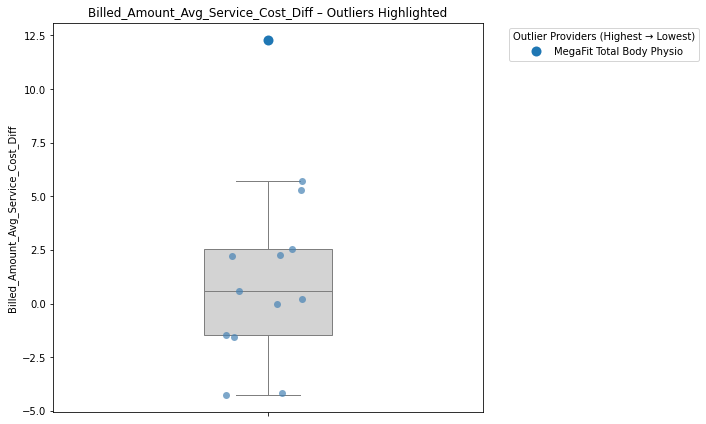

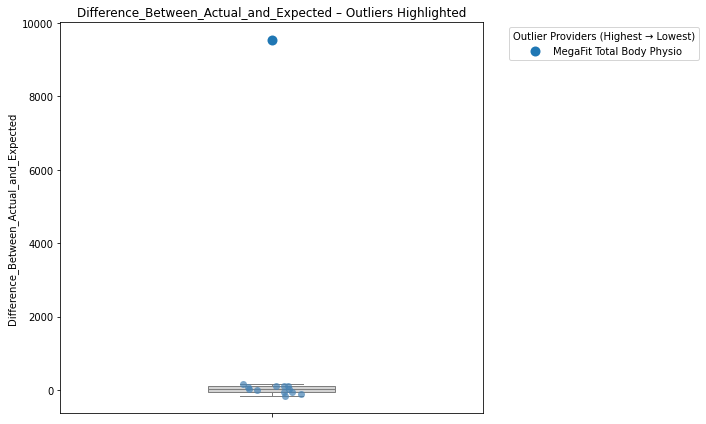


Results for: Physiotherapy Treatment - Standard


,provider_name,service_description,Total_Claims,Average_Billed_Amount,Avg_Cost_NZD,Billed_Amount_Avg_Service_Cost_Diff,Average_Expected_Total_Billed,Actual_Total_Billed,Difference_Between_Actual_and_Expected
0,MegaFit Total Body Physio,Physiotherapy Treatment - Standard,739,84.352368,75,9.352368,55425,62336.40,6911.40
1,Kauri Physiotherapy Clinic,Physiotherapy Treatment - Standard,32,79.675625,75,4.675625,2400,2549.62,149.62
2,Athletes First Clinic,Physiotherapy Treatment - Standard,26,77.696154,75,2.696154,1950,2020.10,70.10
3,Active Rehab Centre,Physiotherapy Treatment - Standard,48,77.308958,75,2.308958,3600,3710.83,110.83
4,AllStar Sports Rehab Co,Physiotherapy Treatment - Standard,91,75.363187,75,0.363187,6825,6858.05,33.05
5,Elite Sports Health,Physiotherapy Treatment - Standard,37,75.283243,75,0.283243,2775,2785.48,10.48
6,Pohutukawa Physio Group,Physiotherapy Treatment - Standard,34,75.093529,75,0.093529,2550,2553.18,3.18
7,Kiwi Peak Sports Medicine,Physiotherapy Treatment - Standard,27,74.976296,75,-0.023704,2025,2024.36,-0.64
8,Tui Physiotherapy Centre,Physiotherapy Treatment - Standard,45,74.784444,75,-0.215556,3375,3365.30,-9.70
9,Springbok Physiotherapy Ltd,Physiotherapy Treatment - Standard,41,74.347561,75,-0.652439,3075,3048.25,-26.75


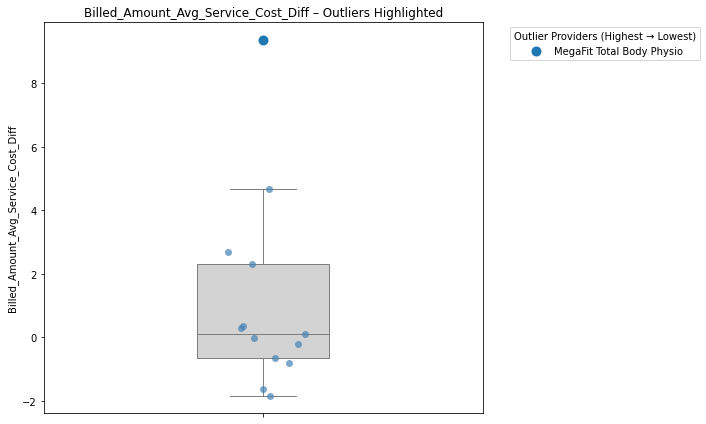

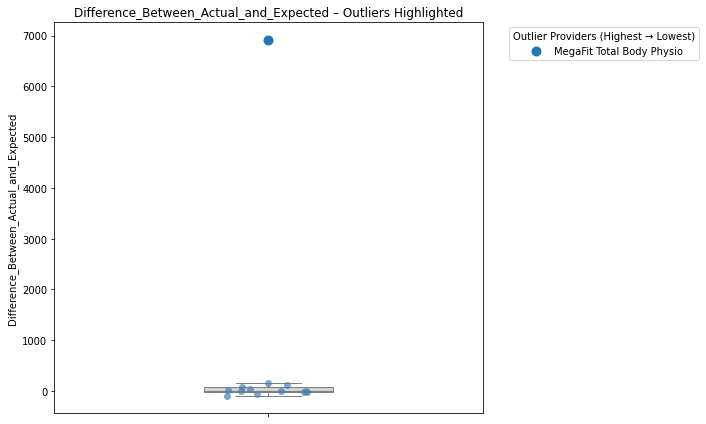


Results for: Physiotherapy Treatment - Extended


,provider_name,service_description,Total_Claims,Average_Billed_Amount,Avg_Cost_NZD,Billed_Amount_Avg_Service_Cost_Diff,Average_Expected_Total_Billed,Actual_Total_Billed,Difference_Between_Actual_and_Expected
0,MegaFit Total Body Physio,Physiotherapy Treatment - Extended,815,123.844405,110,13.844405,89650,100933.19,11283.19
1,Tui Physiotherapy Centre,Physiotherapy Treatment - Extended,36,112.328611,110,2.328611,3960,4043.83,83.83
2,Athletes First Clinic,Physiotherapy Treatment - Extended,35,111.713714,110,1.713714,3850,3909.98,59.98
3,Recovery Plus Rehab,Physiotherapy Treatment - Extended,33,111.060909,110,1.060909,3630,3665.01,35.01
4,Kea Active Physio,Physiotherapy Treatment - Extended,36,110.927500,110,0.927500,3960,3993.39,33.39
5,Pohutukawa Physio Group,Physiotherapy Treatment - Extended,33,110.724242,110,0.724242,3630,3653.90,23.90
6,Active Rehab Centre,Physiotherapy Treatment - Extended,46,110.219348,110,0.219348,5060,5070.09,10.09
7,Kiwi Peak Sports Medicine,Physiotherapy Treatment - Extended,41,110.130488,110,0.130488,4510,4515.35,5.35
8,AllStar Sports Rehab Co,Physiotherapy Treatment - Extended,93,109.744839,110,-0.255161,10230,10206.27,-23.73
9,RapidFix Physiotherapy,Physiotherapy Treatment - Extended,157,109.660191,110,-0.339809,17270,17216.65,-53.35


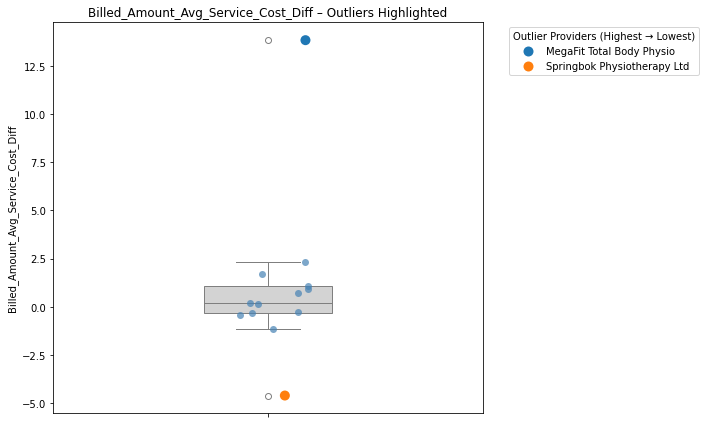

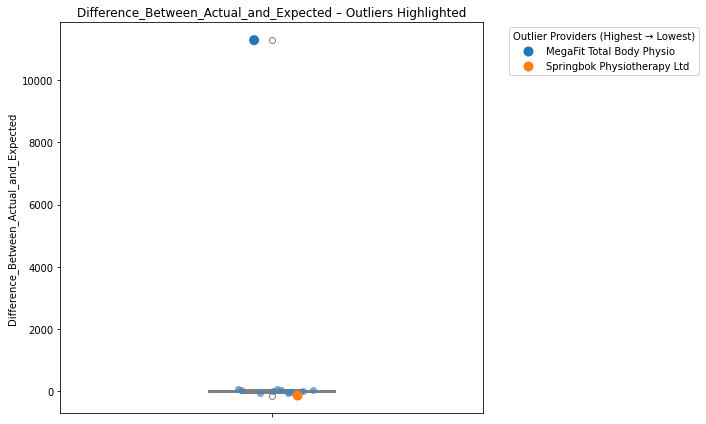


Results for: Dry Needling


,provider_name,service_description,Total_Claims,Average_Billed_Amount,Avg_Cost_NZD,Billed_Amount_Avg_Service_Cost_Diff,Average_Expected_Total_Billed,Actual_Total_Billed,Difference_Between_Actual_and_Expected
0,MegaFit Total Body Physio,Dry Needling,910,72.777989,65,7.777989,59150,66227.97,7077.97
1,RapidFix Physiotherapy,Dry Needling,13,69.752308,65,4.752308,845,906.78,61.78
2,Springbok Physiotherapy Ltd,Dry Needling,28,67.640714,65,2.640714,1820,1893.94,73.94
3,Active Rehab Centre,Dry Needling,42,66.588333,65,1.588333,2730,2796.71,66.71
4,Recovery Plus Rehab,Dry Needling,49,66.399592,65,1.399592,3185,3253.58,68.58
5,AllStar Sports Rehab Co,Dry Needling,101,66.119208,65,1.119208,6565,6678.04,113.04
6,Tui Physiotherapy Centre,Dry Needling,31,65.851613,65,0.851613,2015,2041.40,26.40
7,Kiwi Peak Sports Medicine,Dry Needling,27,65.371852,65,0.371852,1755,1765.04,10.04
8,Elite Sports Health,Dry Needling,35,65.239714,65,0.239714,2275,2283.39,8.39
9,Athletes First Clinic,Dry Needling,33,64.987576,65,-0.012424,2145,2144.59,-0.41


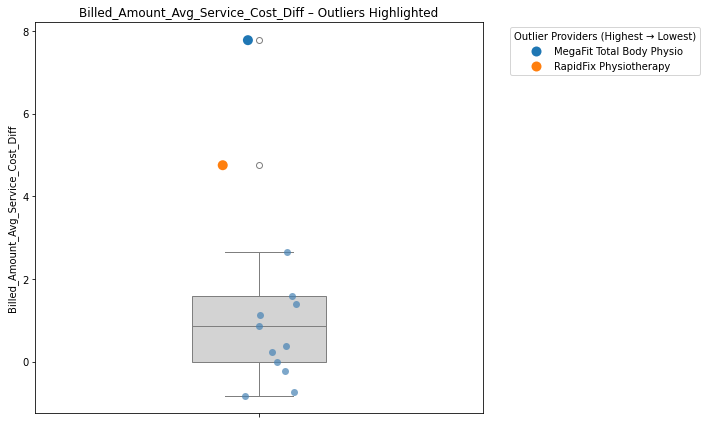

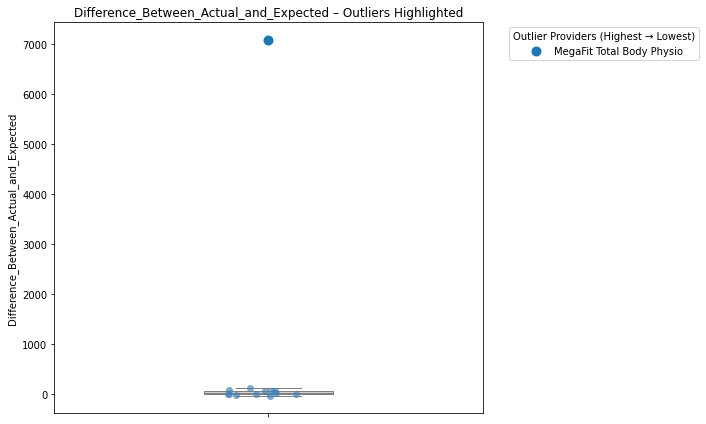


Results for: Sports Massage


,provider_name,service_description,Total_Claims,Average_Billed_Amount,Avg_Cost_NZD,Billed_Amount_Avg_Service_Cost_Diff,Average_Expected_Total_Billed,Actual_Total_Billed,Difference_Between_Actual_and_Expected
0,MegaFit Total Body Physio,Sports Massage,944,95.864926,85,10.864926,80240,90496.49,10256.49
1,Athletes First Clinic,Sports Massage,37,86.948108,85,1.948108,3145,3217.08,72.08
2,Kiwi Peak Sports Medicine,Sports Massage,29,85.903103,85,0.903103,2465,2491.19,26.19
3,Tui Physiotherapy Centre,Sports Massage,36,85.102500,85,0.102500,3060,3063.69,3.69
4,Springbok Physiotherapy Ltd,Sports Massage,28,84.871429,85,-0.128571,2380,2376.40,-3.60
5,AllStar Sports Rehab Co,Sports Massage,83,84.811446,85,-0.188554,7055,7039.35,-15.65
6,Recovery Plus Rehab,Sports Massage,38,84.776053,85,-0.223947,3230,3221.49,-8.51
7,RapidFix Physiotherapy,Sports Massage,17,84.342353,85,-0.657647,1445,1433.82,-11.18
8,Active Rehab Centre,Sports Massage,46,83.832609,85,-1.167391,3910,3856.30,-53.70
9,Pohutukawa Physio Group,Sports Massage,44,83.563409,85,-1.436591,3740,3676.79,-63.21


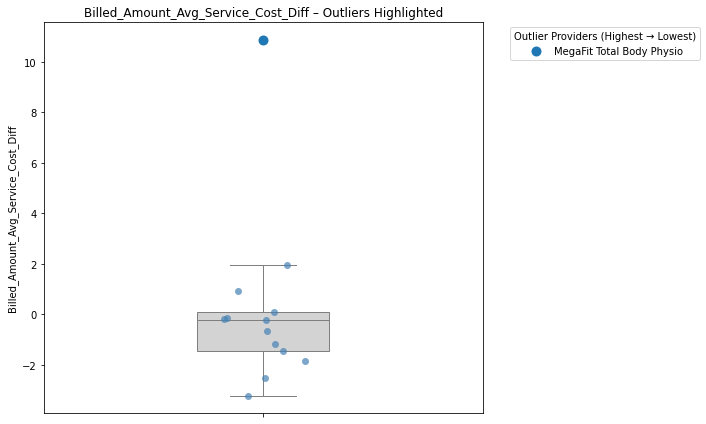

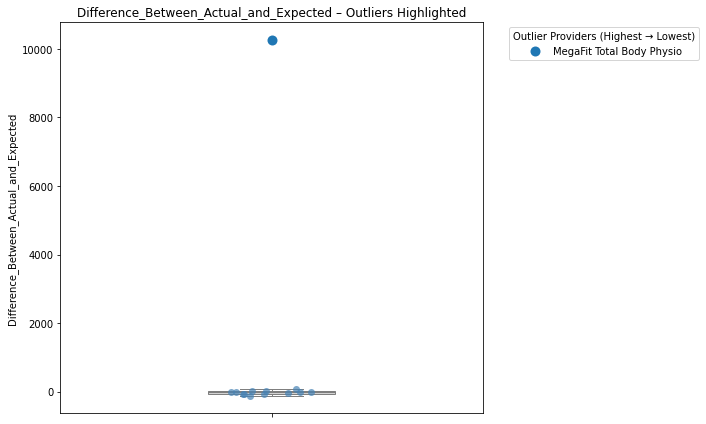


Results for: Chiropractic Initial Consultation


,provider_name,service_description,Total_Claims,Average_Billed_Amount,Avg_Cost_NZD,Billed_Amount_Avg_Service_Cost_Diff,Average_Expected_Total_Billed,Actual_Total_Billed,Difference_Between_Actual_and_Expected
0,GoldStar Wellness Unlimited,Chiropractic Initial Consultation,246,159.467228,90,69.467228,22140,39228.938,17088.938
1,RapidFix Physiotherapy,Chiropractic Initial Consultation,37,90.666757,90,0.666757,3330,3354.670,24.670
2,Fantail Chiropractic Services,Chiropractic Initial Consultation,156,90.331410,90,0.331410,14040,14091.700,51.700
3,Wellness Spine Clinic,Chiropractic Initial Consultation,114,88.859561,90,-1.140439,10260,10129.990,-130.010
4,BackCare Chiropractic,Chiropractic Initial Consultation,127,87.592441,90,-2.407559,11430,11124.240,-305.760


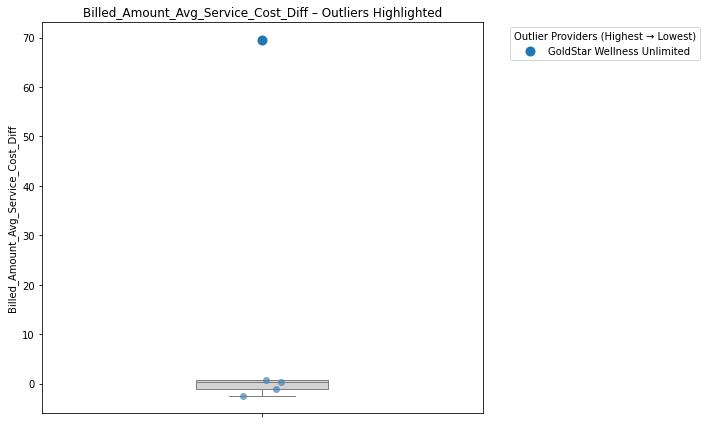

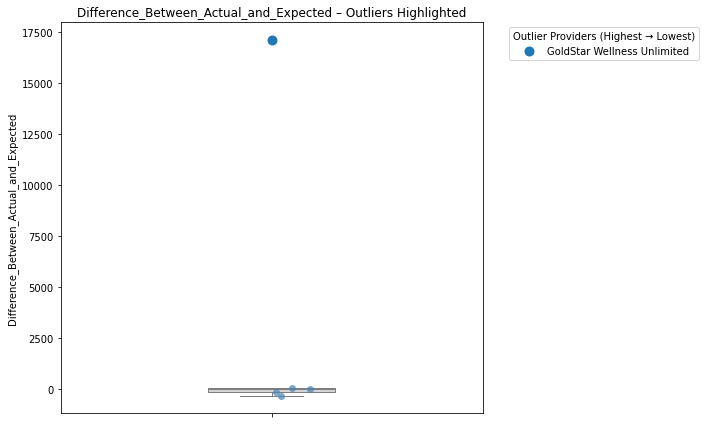


Results for: Chiropractic Adjustment


,provider_name,service_description,Total_Claims,Average_Billed_Amount,Avg_Cost_NZD,Billed_Amount_Avg_Service_Cost_Diff,Average_Expected_Total_Billed,Actual_Total_Billed,Difference_Between_Actual_and_Expected
0,GoldStar Wellness Unlimited,Chiropractic Adjustment,247,124.769166,70,54.769166,17290,30817.984,13527.984
1,BackCare Chiropractic,Chiropractic Adjustment,129,70.414496,70,0.414496,9030,9083.470,53.470
2,Fantail Chiropractic Services,Chiropractic Adjustment,134,70.213433,70,0.213433,9380,9408.600,28.600
3,RapidFix Physiotherapy,Chiropractic Adjustment,33,69.751818,70,-0.248182,2310,2301.810,-8.190
4,Wellness Spine Clinic,Chiropractic Adjustment,135,69.622444,70,-0.377556,9450,9399.030,-50.970


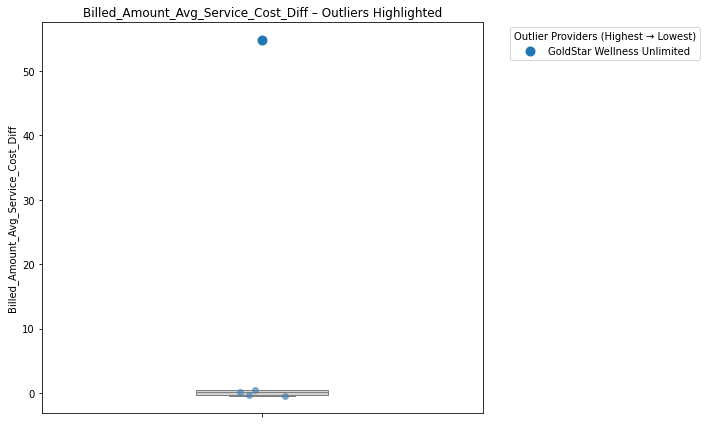

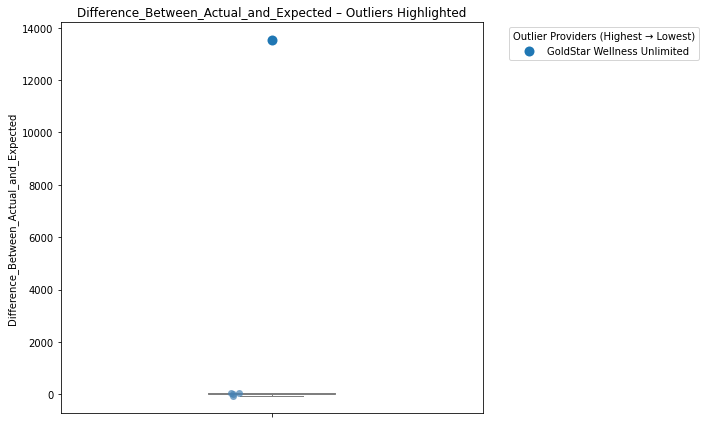


Results for: Spinal Manipulation


,provider_name,service_description,Total_Claims,Average_Billed_Amount,Avg_Cost_NZD,Billed_Amount_Avg_Service_Cost_Diff,Average_Expected_Total_Billed,Actual_Total_Billed,Difference_Between_Actual_and_Expected
0,GoldStar Wellness Unlimited,Spinal Manipulation,272,135.713309,75,60.713309,20400,36914.02,16514.02
1,BackCare Chiropractic,Spinal Manipulation,144,75.398681,75,0.398681,10800,10857.41,57.41
2,Wellness Spine Clinic,Spinal Manipulation,147,74.792517,75,-0.207483,11025,10994.50,-30.50
3,RapidFix Physiotherapy,Spinal Manipulation,41,73.698049,75,-1.301951,3075,3021.62,-53.38
4,Fantail Chiropractic Services,Spinal Manipulation,128,73.042813,75,-1.957187,9600,9349.48,-250.52


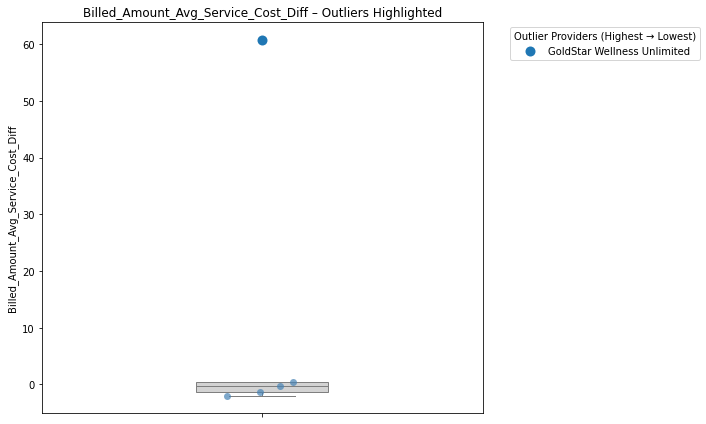

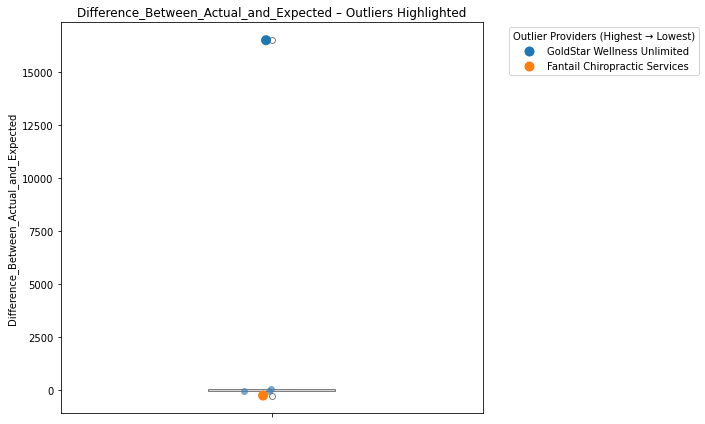


Results for: Osteopathy Initial Assessment


,provider_name,service_description,Total_Claims,Average_Billed_Amount,Avg_Cost_NZD,Billed_Amount_Avg_Service_Cost_Diff,Average_Expected_Total_Billed,Actual_Total_Billed,Difference_Between_Actual_and_Expected
0,RapidFix Physiotherapy,Osteopathy Initial Assessment,39,100.151026,100,0.151026,3900,3905.89,5.89
1,Complete Care Osteopathy,Osteopathy Initial Assessment,192,99.959635,100,-0.040365,19200,19192.25,-7.75
2,Kereru Osteopathy Group,Osteopathy Initial Assessment,222,98.663649,100,-1.336351,22200,21903.33,-296.67
3,Harmony Osteo Clinic,Osteopathy Initial Assessment,201,97.725871,100,-2.274129,20100,19642.90,-457.10


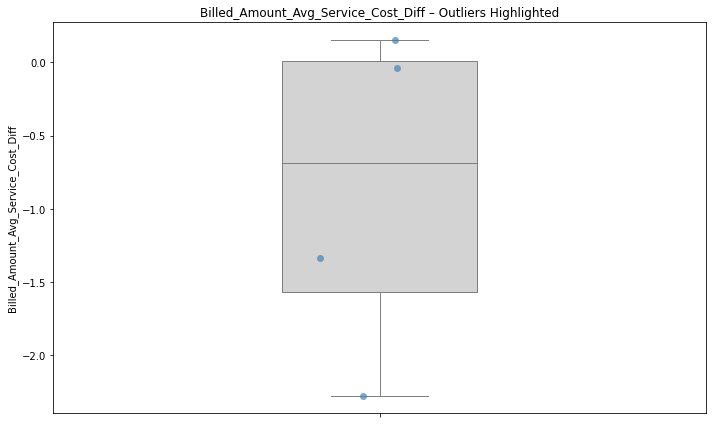

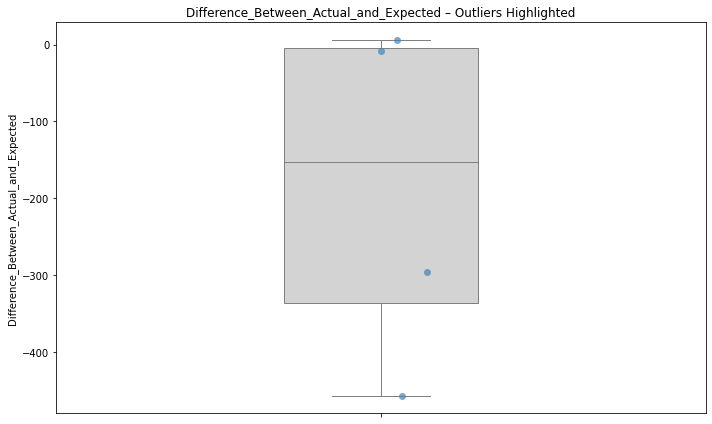


Results for: Osteopathic Treatment


,provider_name,service_description,Total_Claims,Average_Billed_Amount,Avg_Cost_NZD,Billed_Amount_Avg_Service_Cost_Diff,Average_Expected_Total_Billed,Actual_Total_Billed,Difference_Between_Actual_and_Expected
0,RapidFix Physiotherapy,Osteopathic Treatment,35,86.131143,85,1.131143,2975,3014.59,39.59
1,Harmony Osteo Clinic,Osteopathic Treatment,175,85.632229,85,0.632229,14875,14985.64,110.64
2,Complete Care Osteopathy,Osteopathic Treatment,193,84.947927,85,-0.052073,16405,16394.95,-10.05
3,Kereru Osteopathy Group,Osteopathic Treatment,177,84.759209,85,-0.240791,15045,15002.38,-42.62


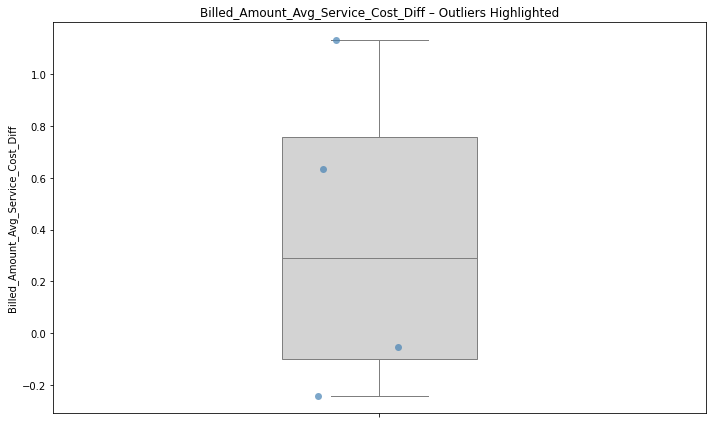

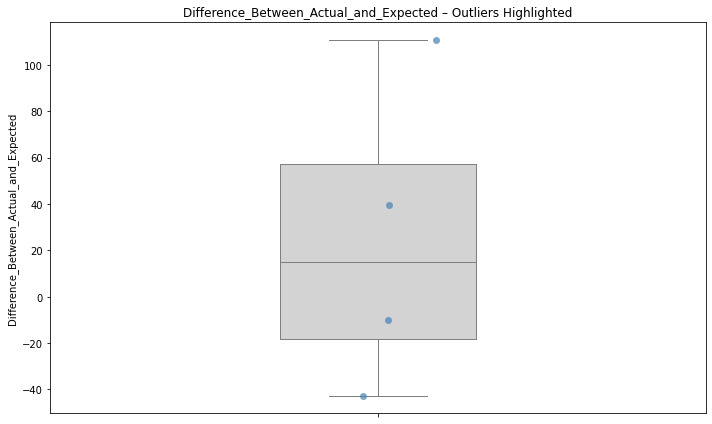


Results for: Remedial Massage - 30min


,provider_name,service_description,Total_Claims,Average_Billed_Amount,Avg_Cost_NZD,Billed_Amount_Avg_Service_Cost_Diff,Average_Expected_Total_Billed,Actual_Total_Billed,Difference_Between_Actual_and_Expected
0,MegaFit Total Body Physio,Remedial Massage - 30min,935,67.483497,60,7.483497,56100,63097.07,6997.07
1,Springbok Physiotherapy Ltd,Remedial Massage - 30min,42,62.221429,60,2.221429,2520,2613.30,93.30
2,RapidFix Physiotherapy,Remedial Massage - 30min,22,61.882727,60,1.882727,1320,1361.42,41.42
3,Kiwi Peak Sports Medicine,Remedial Massage - 30min,38,61.293158,60,1.293158,2280,2329.14,49.14
4,Kauri Physiotherapy Clinic,Remedial Massage - 30min,44,61.288182,60,1.288182,2640,2696.68,56.68
5,Tui Physiotherapy Centre,Remedial Massage - 30min,37,60.628919,60,0.628919,2220,2243.27,23.27
6,Active Rehab Centre,Remedial Massage - 30min,40,60.498000,60,0.498000,2400,2419.92,19.92
7,Kea Active Physio,Remedial Massage - 30min,38,60.300789,60,0.300789,2280,2291.43,11.43
8,AllStar Sports Rehab Co,Remedial Massage - 30min,86,59.761860,60,-0.238140,5160,5139.52,-20.48
9,Elite Sports Health,Remedial Massage - 30min,33,57.920000,60,-2.080000,1980,1911.36,-68.64


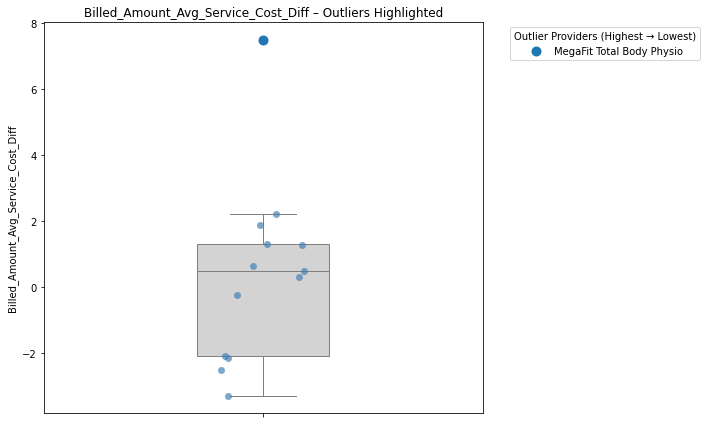

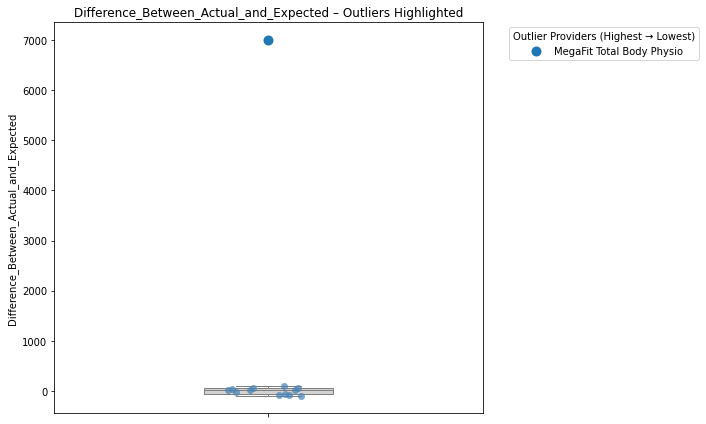


Results for: Remedial Massage - 60min


,provider_name,service_description,Total_Claims,Average_Billed_Amount,Avg_Cost_NZD,Billed_Amount_Avg_Service_Cost_Diff,Average_Expected_Total_Billed,Actual_Total_Billed,Difference_Between_Actual_and_Expected
0,MegaFit Total Body Physio,Remedial Massage - 60min,863,106.417937,95,11.417937,81985,91838.68,9853.68
1,Pohutukawa Physio Group,Remedial Massage - 60min,36,97.787778,95,2.787778,3420,3520.36,100.36
2,Active Rehab Centre,Remedial Massage - 60min,44,96.859318,95,1.859318,4180,4261.81,81.81
3,Kea Active Physio,Remedial Massage - 60min,31,96.274516,95,1.274516,2945,2984.51,39.51
4,AllStar Sports Rehab Co,Remedial Massage - 60min,99,95.000303,95,0.000303,9405,9405.03,0.03
5,RapidFix Physiotherapy,Remedial Massage - 60min,190,94.560947,95,-0.439053,18050,17966.58,-83.42
6,Elite Sports Health,Remedial Massage - 60min,33,94.352727,95,-0.647273,3135,3113.64,-21.36
7,Recovery Plus Rehab,Remedial Massage - 60min,53,94.098302,95,-0.901698,5035,4987.21,-47.79
8,Kiwi Peak Sports Medicine,Remedial Massage - 60min,34,93.717647,95,-1.282353,3230,3186.40,-43.60
9,Tui Physiotherapy Centre,Remedial Massage - 60min,30,93.529667,95,-1.470333,2850,2805.89,-44.11


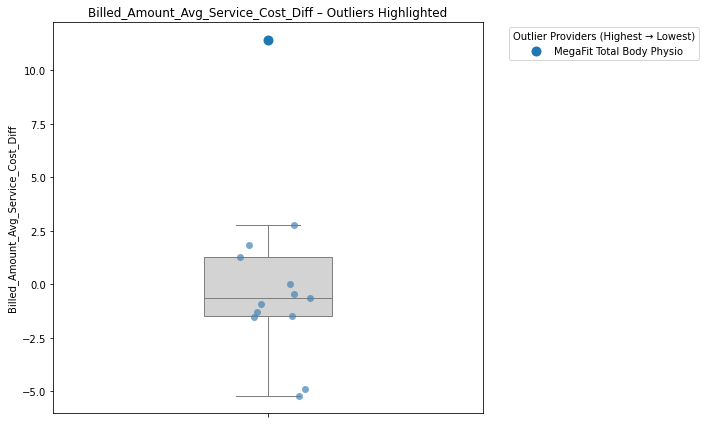

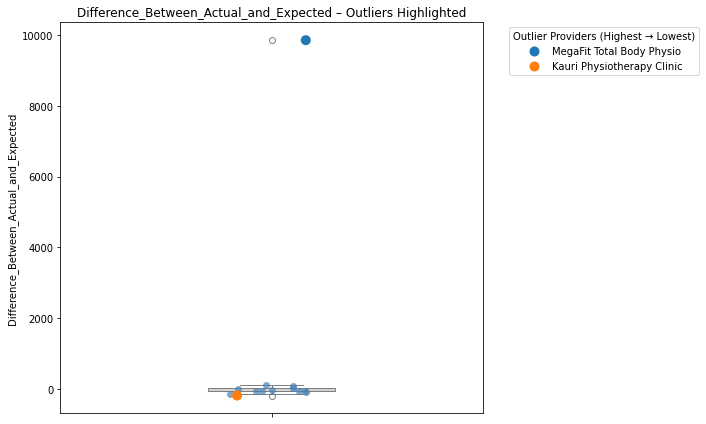


Results for: Acupuncture Treatment


,provider_name,service_description,Total_Claims,Average_Billed_Amount,Avg_Cost_NZD,Billed_Amount_Avg_Service_Cost_Diff,Average_Expected_Total_Billed,Actual_Total_Billed,Difference_Between_Actual_and_Expected
0,Springbok Physiotherapy Ltd,Acupuncture Treatment,25,70.396400,70,0.396400,1750,1759.91,9.91
1,Tui Physiotherapy Centre,Acupuncture Treatment,27,69.890741,70,-0.109259,1890,1887.05,-2.95
2,RapidFix Physiotherapy,Acupuncture Treatment,19,69.494737,70,-0.505263,1330,1320.40,-9.60
3,Kauri Physiotherapy Clinic,Acupuncture Treatment,31,68.801935,70,-1.198065,2170,2132.86,-37.14
4,Pohutukawa Physio Group,Acupuncture Treatment,28,68.497857,70,-1.502143,1960,1917.94,-42.06
5,Kea Active Physio,Acupuncture Treatment,30,67.268333,70,-2.731667,2100,2018.05,-81.95


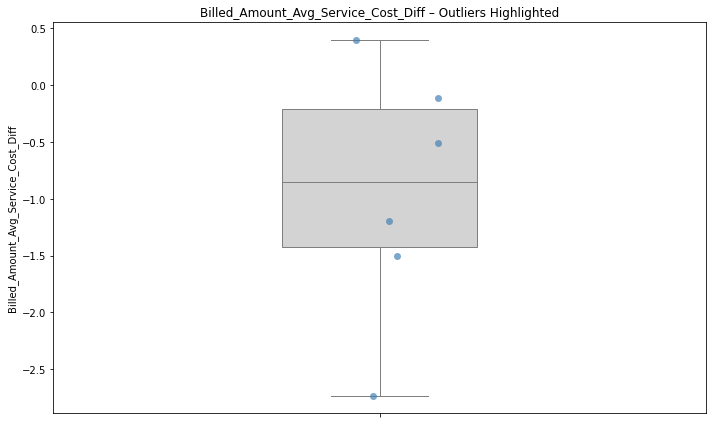

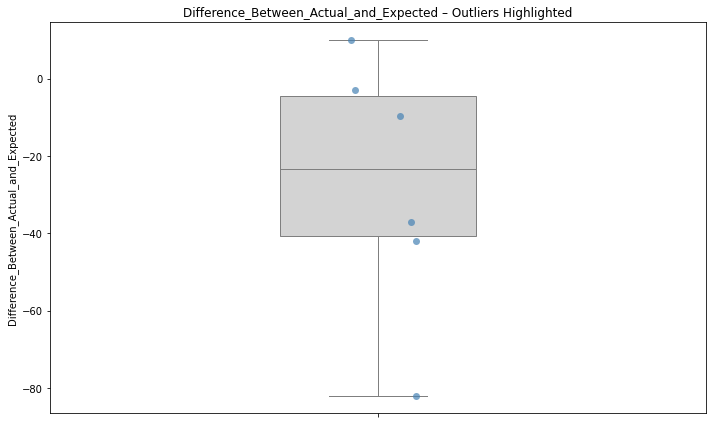


Results for: Exercise Rehabilitation Session


,provider_name,service_description,Total_Claims,Average_Billed_Amount,Avg_Cost_NZD,Billed_Amount_Avg_Service_Cost_Diff,Average_Expected_Total_Billed,Actual_Total_Billed,Difference_Between_Actual_and_Expected
0,MegaFit Total Body Physio,Exercise Rehabilitation Session,867,90.319193,80,10.319193,69360,78306.74,8946.74
1,Pohutukawa Physio Group,Exercise Rehabilitation Session,32,81.610938,80,1.610938,2560,2611.55,51.55
2,Springbok Physiotherapy Ltd,Exercise Rehabilitation Session,44,80.619545,80,0.619545,3520,3547.26,27.26
3,Kea Active Physio,Exercise Rehabilitation Session,37,80.174865,80,0.174865,2960,2966.47,6.47
4,AllStar Sports Rehab Co,Exercise Rehabilitation Session,107,79.947850,80,-0.052150,8560,8554.42,-5.58
5,RapidFix Physiotherapy,Exercise Rehabilitation Session,31,79.815806,80,-0.184194,2480,2474.29,-5.71
6,Active Rehab Centre,Exercise Rehabilitation Session,39,79.364359,80,-0.635641,3120,3095.21,-24.79
7,Elite Sports Health,Exercise Rehabilitation Session,38,79.353684,80,-0.646316,3040,3015.44,-24.56
8,Kiwi Peak Sports Medicine,Exercise Rehabilitation Session,41,79.201463,80,-0.798537,3280,3247.26,-32.74
9,Recovery Plus Rehab,Exercise Rehabilitation Session,33,79.001212,80,-0.998788,2640,2607.04,-32.96


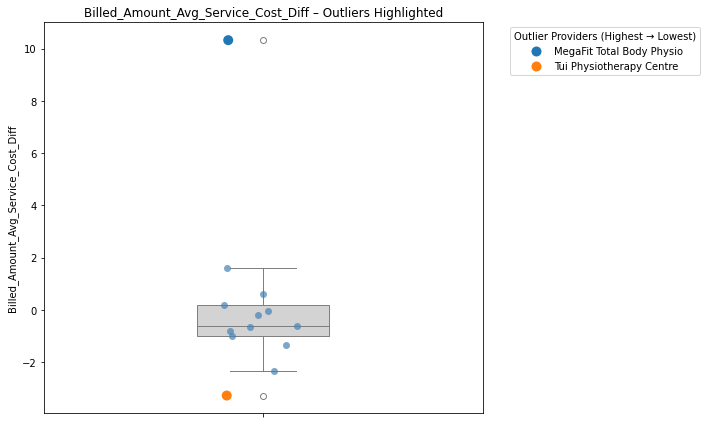

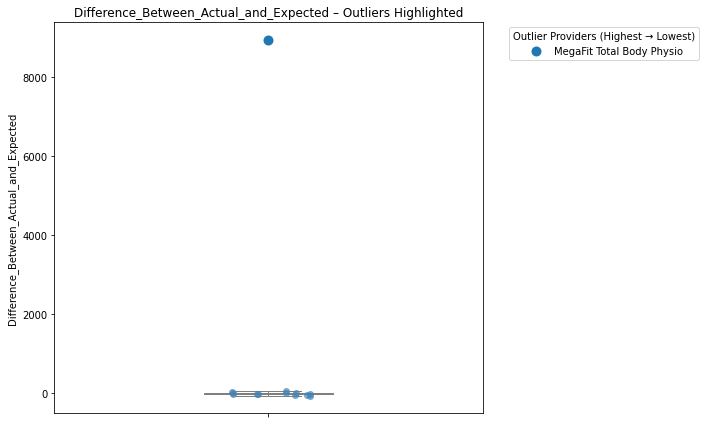


Results for: Hydrotherapy Session


,provider_name,service_description,Total_Claims,Average_Billed_Amount,Avg_Cost_NZD,Billed_Amount_Avg_Service_Cost_Diff,Average_Expected_Total_Billed,Actual_Total_Billed,Difference_Between_Actual_and_Expected
0,MegaFit Total Body Physio,Hydrotherapy Session,883,101.187565,90,11.187565,79470,89348.62,9878.62
1,Active Rehab Centre,Hydrotherapy Session,36,94.356389,90,4.356389,3240,3396.83,156.83
2,Kea Active Physio,Hydrotherapy Session,28,92.190000,90,2.190000,2520,2581.32,61.32
3,Recovery Plus Rehab,Hydrotherapy Session,56,91.513393,90,1.513393,5040,5124.75,84.75
4,Kauri Physiotherapy Clinic,Hydrotherapy Session,26,91.278846,90,1.278846,2340,2373.25,33.25
5,Elite Sports Health,Hydrotherapy Session,35,91.040286,90,1.040286,3150,3186.41,36.41
6,AllStar Sports Rehab Co,Hydrotherapy Session,91,89.058352,90,-0.941648,8190,8104.31,-85.69
7,Pohutukawa Physio Group,Hydrotherapy Session,42,88.584762,90,-1.415238,3780,3720.56,-59.44
8,Athletes First Clinic,Hydrotherapy Session,42,88.480952,90,-1.519048,3780,3716.20,-63.80
9,Springbok Physiotherapy Ltd,Hydrotherapy Session,27,88.426296,90,-1.573704,2430,2387.51,-42.49


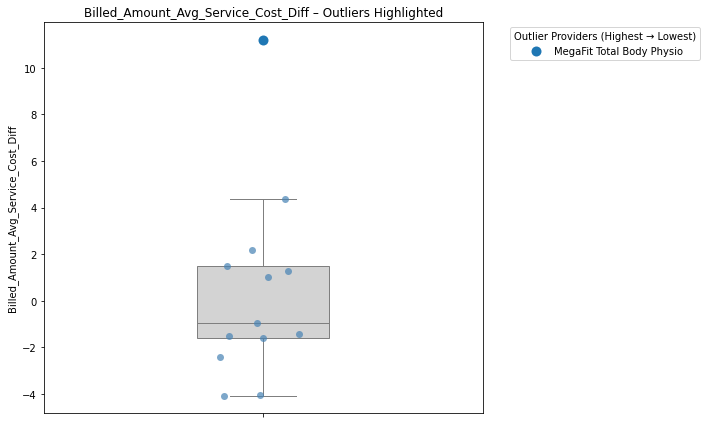

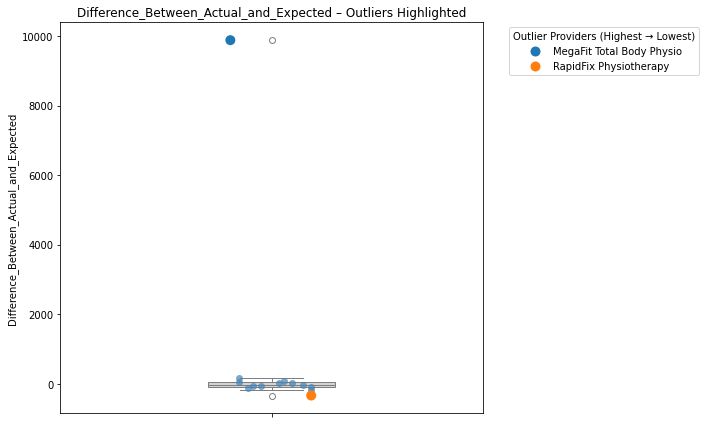


Results for: Sports Injury Assessment


,provider_name,service_description,Total_Claims,Average_Billed_Amount,Avg_Cost_NZD,Billed_Amount_Avg_Service_Cost_Diff,Average_Expected_Total_Billed,Actual_Total_Billed,Difference_Between_Actual_and_Expected
0,Elite Sports Health,Sports Injury Assessment,39,113.989744,110,3.989744,4290,4445.60,155.60
1,Athletes First Clinic,Sports Injury Assessment,32,111.707813,110,1.707813,3520,3574.65,54.65
2,Kiwi Peak Sports Medicine,Sports Injury Assessment,24,109.388750,110,-0.611250,2640,2625.33,-14.67
3,RapidFix Physiotherapy,Sports Injury Assessment,34,109.287941,110,-0.712059,3740,3715.79,-24.21
4,AllStar Sports Rehab Co,Sports Injury Assessment,112,108.943036,110,-1.056964,12320,12201.62,-118.38


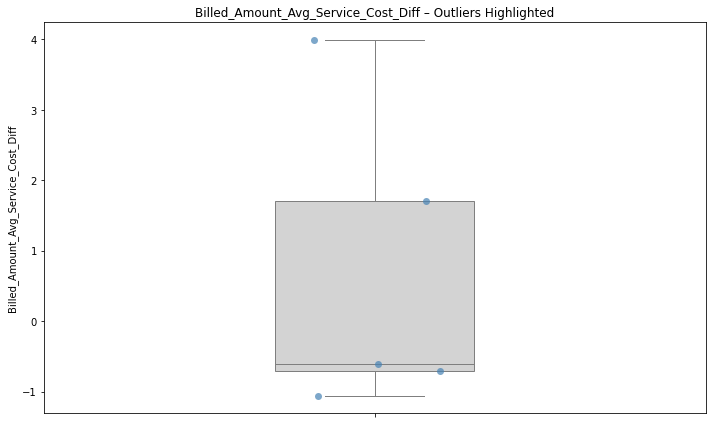

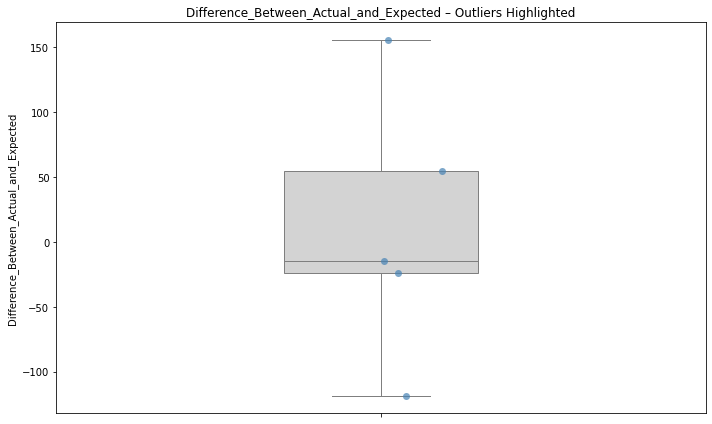


Results for: Sports Taping/Strapping


,provider_name,service_description,Total_Claims,Average_Billed_Amount,Avg_Cost_NZD,Billed_Amount_Avg_Service_Cost_Diff,Average_Expected_Total_Billed,Actual_Total_Billed,Difference_Between_Actual_and_Expected
0,Springbok Physiotherapy Ltd,Sports Taping/Strapping,30,47.112667,45,2.112667,1350,1413.38,63.38
1,Kea Active Physio,Sports Taping/Strapping,30,46.960333,45,1.960333,1350,1408.81,58.81
2,Kiwi Peak Sports Medicine,Sports Taping/Strapping,38,46.698421,45,1.698421,1710,1774.54,64.54
3,Elite Sports Health,Sports Taping/Strapping,37,46.270270,45,1.270270,1665,1712.00,47.00
4,Athletes First Clinic,Sports Taping/Strapping,38,45.658421,45,0.658421,1710,1735.02,25.02
5,Tui Physiotherapy Centre,Sports Taping/Strapping,34,45.167941,45,0.167941,1530,1535.71,5.71
6,Kauri Physiotherapy Clinic,Sports Taping/Strapping,40,44.949750,45,-0.050250,1800,1797.99,-2.01
7,Pohutukawa Physio Group,Sports Taping/Strapping,36,44.632778,45,-0.367222,1620,1606.78,-13.22
8,RapidFix Physiotherapy,Sports Taping/Strapping,19,44.425789,45,-0.574211,855,844.09,-10.91
9,AllStar Sports Rehab Co,Sports Taping/Strapping,115,43.557652,45,-1.442348,5175,5009.13,-165.87


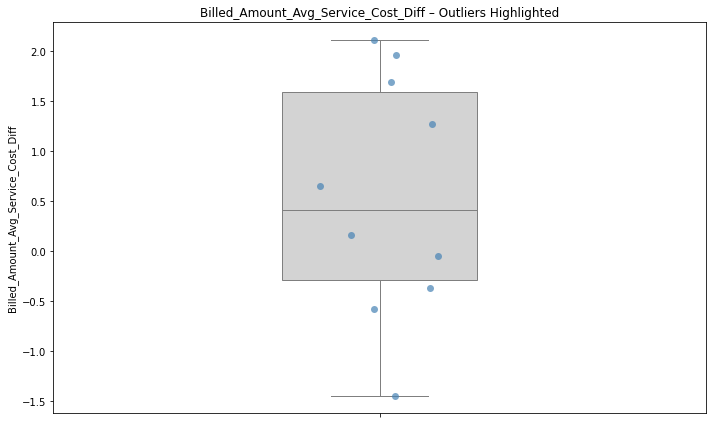

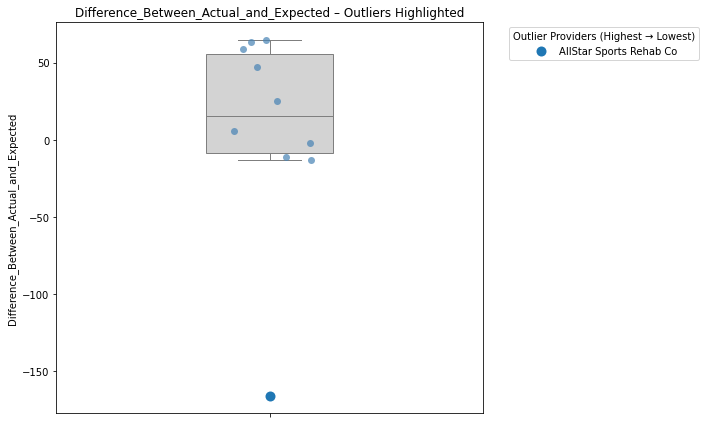

In [40]:
# Getting the difference between total actual billed_amount and total expected (average_cost) for each provider and service type.
# PHYS001: 'Initial Physiotherapy Assessment'

services = [
    'Initial Physiotherapy Assessment',
    'Physiotherapy Treatment - Standard',
    'Physiotherapy Treatment - Extended',
    'Dry Needling',
    'Sports Massage',
    'Chiropractic Initial Consultation',
    'Chiropractic Adjustment',
    'Spinal Manipulation',
    'Osteopathy Initial Assessment',
    'Osteopathic Treatment',
    'Remedial Massage - 30min',
    'Remedial Massage - 60min',
    'Acupuncture Treatment',
    'Exercise Rehabilitation Session',
    'Hydrotherapy Session',
    'Sports Injury Assessment',
    'Sports Taping/Strapping'
]

sql_query = """
SELECT provider_name, 
    service_description,
    COUNT(claim_id) AS Total_Claims,
    SUM(billed_amount)/COUNT(claim_id) AS Average_Billed_Amount,
    Avg_Cost_NZD,
    SUM(billed_amount)/COUNT(claim_id) - Avg_Cost_NZD AS Billed_Amount_Avg_Service_Cost_Diff,
    Avg_Cost_NZD * COUNT(claim_id) AS Average_Expected_Total_Billed,
    SUM(billed_amount) AS Actual_Total_Billed,
    SUM(billed_amount) - (Avg_Cost_NZD * COUNT(claim_id)) AS Difference_Between_Actual_and_Expected
FROM medical_claims_df 
WHERE Avg_Cost_NZD IS NOT NULL 
  AND service_description = ?
GROUP BY provider_name, service_description, Avg_Cost_NZD
ORDER BY SUM(billed_amount)/COUNT(claim_id) - Avg_Cost_NZD DESC
"""



for service in services:
    
    df = duckdb.query(sql_query, params=[service]).df()
    
    print(f"\nResults for: {service}")
    display(df)
    
    if not df.empty and len(df) > 1:
        
        #  Average billed vs expected per claim
        plot_highlight_provider_outliers(
            df,
            "Billed_Amount_Avg_Service_Cost_Diff"
        )
        
        #  Total actual vs expected difference
        plot_highlight_provider_outliers(
            df,
            "Difference_Between_Actual_and_Expected"
        )

RapidFix Physiotheraphy, for Dry Needling services has billed \\$4.75 higher than the average for each claim. Large amount of the bill also comes from Manual Therapy - Advanced, which doesn't have an average_cost

In [41]:
# One of the service_code didn't have an Avg_Cost. This service was Manual Therapy - Advanced. It seems like this is where 
# RapidFix Physiotherapy claimed the most bill.

sql_query = """

SELECT provider_name, 
    service_description,
    COUNT(claim_id) AS Total_Claims,
    SUM(billed_amount)/COUNT(claim_id) AS Average_Billed_Amount,
    Avg_Cost_NZD,
    Avg_Cost_NZD * COUNT(claim_id) AS Average_Expected_Total_Billed,
    SUM(billed_amount) AS Actual_Total_Billed,
    SUM(billed_amount) - (Avg_Cost_NZD * COUNT(claim_id)) AS Difference_Between_Actual_and_Expected
FROM medical_claims_df 
WHERE Avg_Cost_NZD IS NULL
GROUP BY provider_name,service_description, Avg_Cost_NZD
ORDER BY SUM(billed_amount) - (Avg_Cost_NZD * COUNT(claim_id)) DESC

"""

# Run Query
duckdb.query(sql_query).df()


,provider_name,service_description,Total_Claims,Average_Billed_Amount,Avg_Cost_NZD,Average_Expected_Total_Billed,Actual_Total_Billed,Difference_Between_Actual_and_Expected
0,Pohutukawa Physio Group,Manual Therapy - Advanced,37,120.668378,<NA>,<NA>,4464.73,NaN
1,Kea Active Physio,Manual Therapy - Advanced,28,116.985714,<NA>,<NA>,3275.60,NaN
2,Tui Physiotherapy Centre,Manual Therapy - Advanced,27,127.909630,<NA>,<NA>,3453.56,NaN
3,Springbok Physiotherapy Ltd,Manual Therapy - Advanced,30,121.076000,<NA>,<NA>,3632.28,NaN
4,Kauri Physiotherapy Clinic,Manual Therapy - Advanced,27,126.139630,<NA>,<NA>,3405.77,NaN
5,RapidFix Physiotherapy,Manual Therapy - Advanced,177,123.640452,<NA>,<NA>,21884.36,NaN


In [42]:
# Display all rows
pd.set_option("display.max_rows", None)

In [43]:
# Display total_claims per provider per_service_description
sql_query = """

SELECT provider_name, 
       service_description,
       COUNT(claim_id) AS 'Total_Claims',
       SUM(billed_amount) AS 'Total_Billed'
FROM medical_claims_df 
GROUP BY provider_name,service_description
ORDER BY SUM(billed_amount) DESC
-- ORDER BY provider_name,COUNT(claim_id) DESC

"""

# Run Query
duckdb.query(sql_query).df()


,provider_name,service_description,Total_Claims,Total_Billed
0,MegaFit Total Body Physio,Physiotherapy Treatment - Extended,815,100933.190
1,MegaFit Total Body Physio,Remedial Massage - 60min,863,91838.680
2,MegaFit Total Body Physio,Sports Massage,944,90496.490
3,MegaFit Total Body Physio,Hydrotherapy Session,883,89348.620
4,MegaFit Total Body Physio,Initial Physiotherapy Assessment,777,83349.500
5,MegaFit Total Body Physio,Exercise Rehabilitation Session,867,78306.740
6,MegaFit Total Body Physio,Dry Needling,910,66227.970
7,MegaFit Total Body Physio,Remedial Massage - 30min,935,63097.070
8,MegaFit Total Body Physio,Physiotherapy Treatment - Standard,739,62336.400
9,GoldStar Wellness Unlimited,Chiropractic Initial Consultation,246,39228.938


In [44]:
# Display total_claims per of AllStar Sports Rehab Co per_service_description
sql_query = """

SELECT provider_name, 
       service_description,
       COUNT(claim_id) AS 'Total_Claims',
       SUM(billed_amount) AS 'Total_Billed'
FROM medical_claims_df 
WHERE provider_name = 'AllStar Sports Rehab Co'
GROUP BY provider_name,service_description
ORDER BY SUM(billed_amount) DESC
-- ORDER BY provider_name,COUNT(claim_id) DESC

"""

# Run Query
duckdb.query(sql_query).df()


,provider_name,service_description,Total_Claims,Total_Billed
0,AllStar Sports Rehab Co,Sports Injury Assessment,112,12201.62
1,AllStar Sports Rehab Co,Physiotherapy Treatment - Extended,93,10206.27
2,AllStar Sports Rehab Co,Remedial Massage - 60min,99,9405.03
3,AllStar Sports Rehab Co,Initial Physiotherapy Assessment,93,8856.53
4,AllStar Sports Rehab Co,Exercise Rehabilitation Session,107,8554.42
5,AllStar Sports Rehab Co,Hydrotherapy Session,91,8104.31
6,AllStar Sports Rehab Co,Sports Massage,83,7039.35
7,AllStar Sports Rehab Co,Physiotherapy Treatment - Standard,91,6858.05
8,AllStar Sports Rehab Co,Dry Needling,101,6678.04
9,AllStar Sports Rehab Co,Remedial Massage - 30min,86,5139.52


<h1>Insights Gathered </h1>

From the quick activity, in short, the following needs to be investigated:

<ol>
    <li> <strong>MegaFit Total Body Physio </strong> - It's billed_amount is considerably higher than any provider and avg_cost. </li>
    <li> <strong>GoldStar Wellness Unlimited </strong> - Has 5 clients, which has generated an average of billed_amount $21392.188400 with an average of claim per client being 153. For reference the second-highest has 6 (MegaFit Total Body Physio). </li>
    <li> <strong>RapidFix Physiotherapy </strong> - Probably is over-charging on Dry Needling services. Otherwise looks okay. </li>
    <li> There are data-related issues as well. For example client_age changing several times within the year, as well as client_tla

<h1>Next Steps: </h1>
<ol>
    <li> <strong> Dashboarding: </strong> Creating a Power BI/Tableau would be useful to tease out more insights (espeically considering time-variants). </li>
    <li> <strong> Internal Frauding: </strong> At this stage, we only looked at suspicious activies potentially made by providers. However, providers can only bill for their services. The <strong>allowed_amount</strong> and <strong>paid_amount</strong> is internally decided. Hence, next steps would be analyze this. Things to find out if there are instance where the allowed_amount is 100% of billed_amount and if paid_amount is 100% of the billed amount. </li>
    <li> <strong>Machine Learning:</strong> Would be interesting to do custering (eg K-Means) on several created variables. Would be also interesting to build classification models based on past data where fraud has been made. </li>
    <li> <strong>Statisical Analysis:</strong> Such as understanding relationships would be great as well!

<h1> Explaining: </h1>
<ol>
   <li> Data Analyst: Box-plots were used to determine outliers. From this, 2 providers showed consistently being deemed as outliers in various metrics, such as billed_amount, averag_bill_amount_per_claim, etc. There were data-issues as well. This included things such client_age changing several times just within a few days as well as its client_tla. There doesn't seem to be any incentive for providers to change client_age, and client_age is something that might be coming from our internal systems. Hence, this needs to be considered as well. Other additional analysis can be possible such as Regression Analysis to understand relationships, and hold other variables constant. Methods such as clustering could be applied as well, and if there are previous instances/data where fraud has been detected, this could be used for creating classification-based models using Decision Trees, Logistic Regressions, etc. </li>
    <li> A non-data savvy fraud investigator: Most providers had the billed_amount closer to the average_cost for that particular service. However, 2 providers, MegaFit Total Body Physio and GoldStar Wellness Unlimited and considerably higher billed_amount. Furthermore, GoldStar Wellness Unlimited only has 5 clients, which generated an average billed_amount of \\ roughly $21,000. Given the consistency of raising suspicion in several metrics, it is advisible to conduct an investigation. </li>
    <li>A Senior decision maker: Our analysis identified a small number of providers whose billing behaviour differs from other provider benchmarks. These providers account for a disproportionate share of claims and show elevated pricing and service frequency patterns. Although this doesn't mean for certainity there's fraud, it does highlight risk. A recomendation would be change the perception that fraud only comes from external sources, it can occur internally as well. For example <a
    href="https://www.sfo.govt.nz/media-cases/media-releases/husband-and-wife-admit-2-million-fraud-against-oranga-tamariki-in-sfo-case">that committed internally at Oranga Tamariki.</a> Hence, ensure that there are internal controls such as separation of duties, etc. and proper assessments.